In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,RobustScaler,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings(action='ignore')

In [2]:
plt.style.use('bmh')

In [3]:
import os
print(os.getcwd())

C:\Users\Jay\Desktop\product-return-prediction\notebook


In [4]:
df_dict = pd.read_excel("../data/online_retail_II.xlsx", sheet_name=None)

In [5]:
df_dict.keys()

dict_keys(['Year 2009-2010', 'Year 2010-2011'])

In [6]:
df_dict['Year 2009-2010'].shape, df_dict['Year 2010-2011'].shape

((525461, 8), (541910, 8))

In [7]:
df1 = df_dict['Year 2009-2010']
df2 = df_dict['Year 2010-2011']

In [8]:
df = pd.concat([df1, df2], ignore_index=True)

In [9]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [10]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [12]:
df.shape

(1067371, 8)

In [13]:
df.isna().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [14]:
df.duplicated().sum()

34335

In [15]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [16]:
df = df.sort_values('InvoiceDate').reset_index(drop=True)

In [17]:
df['is_return'] = ((df['Invoice'].str.startswith('C')) | (df['Quantity'] < 0)).astype(int)

In [18]:
print("Return Distribution:\n", df['is_return'].value_counts(normalize=True))

Return Distribution:
 0    0.981736
1    0.018264
Name: is_return, dtype: float64


In [19]:
df[df['is_return']==1]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_return
178,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,1
179,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia,1
180,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia,1
181,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia,1
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,1
...,...,...,...,...,...,...,...,...,...
1065910,C581490,22178,VICTORIAN GLASS HANGING T-LIGHT,-12,2011-12-09 09:57:00,1.95,14397.0,United Kingdom,1
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom,1
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom,1
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,1


In [19]:
df['Quantity'] = df['Quantity'].abs()
df['Price'] = df['Price'].abs()

In [20]:
df = df[df['Price'] > 0].copy()

In [21]:
df.sample(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_return
815109,562276,22845,VINTAGE CREAM CAT FOOD CONTAINER,2,2011-08-04 10:23:00,6.35,17735.0,United Kingdom,0
661945,547964,21166,COOK WITH WINE METAL SIGN,1,2011-03-28 15:45:00,4.13,NaN,United Kingdom,0
130460,501810,22417,PACK OF 60 SPACEBOY CAKE CASES,24,2010-03-19 14:41:00,0.55,14911.0,EIRE,0
620293,544431,22991,GIRAFFE WOODEN RULER,1,2011-02-18 15:49:00,1.95,NaN,United Kingdom,0
230260,511641,10002,INFLATABLE POLITICAL GLOBE,4,2010-06-09 13:24:00,0.85,NaN,United Kingdom,0


In [22]:
df['order_value'] = df['Price']*df['Quantity']

In [23]:
df['month'] = df['InvoiceDate'].dt.month

In [24]:
df['hour'] = df['InvoiceDate'].dt.hour

In [25]:
df['day_of_week'] = df['InvoiceDate'].dt.dayofweek

In [26]:
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

In [27]:
df['Customer ID'].isna().sum()

236876

In [28]:
df.dropna(subset=['Customer ID'],inplace=True)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 824293 entries, 0 to 1067370
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      824293 non-null  object        
 1   StockCode    824293 non-null  object        
 2   Description  824293 non-null  object        
 3   Quantity     824293 non-null  int64         
 4   InvoiceDate  824293 non-null  datetime64[ns]
 5   Price        824293 non-null  float64       
 6   Customer ID  824293 non-null  float64       
 7   Country      824293 non-null  object        
 8   is_return    824293 non-null  int32         
 9   order_value  824293 non-null  float64       
 10  month        824293 non-null  int64         
 11  hour         824293 non-null  int64         
 12  day_of_week  824293 non-null  int64         
 13  is_weekend   824293 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(2), int64(4), object(4)
memory usage: 88.0+

#### Temporal Split to Prevent Data Leakage

In [30]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

In [31]:
for i,(train_index,val_index) in enumerate(tscv.split(df)):
    train_df = df.iloc[train_index]
    test_df = df.iloc[val_index]

In [32]:
train_df.shape,test_df.shape

((686911, 14), (137382, 14))

##### Customer Return Rate

In [33]:
crr = train_df.groupby('Customer ID')['is_return'].mean()

In [34]:
train_df['cust_return_rate'] = train_df['Customer ID'].map(crr)
test_df['cust_return_rate'] = test_df['Customer ID'].map(crr)

In [35]:
print(train_df['cust_return_rate'].mean())
print(test_df['cust_return_rate'].mean())

0.0234542757358668
0.020638797754258222


In [36]:
test_df['cust_return_rate'].isna().sum() ### new customers which has Nan as return rate

20786

In [37]:
### fill that by train mean
train_mean = train_df['is_return'].mean()

In [38]:
test_df['cust_return_rate'] = test_df['cust_return_rate'].fillna(train_mean)

##### Stock Return Rate

In [39]:
stock_rr = train_df.groupby('StockCode')['is_return'].mean()

In [40]:
train_df['stock_return_rate'] = train_df['StockCode'].map(stock_rr)
test_df['stock_return_rate'] = test_df['StockCode'].map(stock_rr)

In [41]:
test_df['stock_return_rate'].fillna(train_mean,inplace=True)

In [42]:
train_df['stock_return_rate'].median()

0.012605042016806723

##### Unique product per Invoice

In [43]:
unique_product = train_df.groupby('Invoice')['StockCode'].nunique().to_dict()

In [44]:
train_df['unique_items'] = train_df['Invoice'].map(unique_product)

In [45]:
test_df['unique_items'] = test_df['Invoice'].map(unique_product)

In [46]:
test_df['unique_items'].isna().sum()  ## new products

137382

In [47]:
test_df['unique_items'].fillna(1,inplace=True)

##### Customer Recency (Days since the customer's last purchase)

In [48]:
curr_date = train_df['InvoiceDate'].max()

In [49]:
last_purchase = train_df.groupby('Customer ID')['InvoiceDate'].max()

In [50]:
cust_recency_map = (curr_date - last_purchase).dt.days.to_dict()

In [51]:
train_df['cust_recency'] = train_df['Customer ID'].map(cust_recency_map).fillna(999)
test_df['cust_recency'] = test_df['Customer ID'].map(cust_recency_map).fillna(999)

##### Top 15 Countries

In [52]:
top_countries = train_df['Country'].value_counts().head(10).index.tolist()

In [53]:
def get_countries(country):
    return country if country in top_countries else "other"

In [54]:
train_df['Country'] = train_df['Country'].apply(get_countries)
test_df['Country'] = test_df['Country'].apply(get_countries)

##### Return Recency (Days since last return)

In [55]:
rr_map = (curr_date - train_df[train_df['is_return']==1].groupby('Customer ID')['InvoiceDate'].max()).dt.days.to_dict()

In [56]:
# Days since last return
train_df['return_recency'] = train_df['Customer ID'].map(rr_map).fillna(365)
test_df['return_recency'] = test_df['Customer ID'].map(rr_map).fillna(365)

##### Order Value Bucket

In [57]:
train_df['order_value_bucket'] = pd.qcut(train_df['order_value'],q=5,labels=False)
test_df['order_value_bucket'] = pd.qcut(test_df['order_value'],q=5,labels=False)

In [58]:
train_df.groupby('order_value_bucket')['is_return'].mean()

order_value_bucket
0    0.031450
1    0.028670
2    0.020380
3    0.013269
4    0.022712
Name: is_return, dtype: float64

##### Quantity Bucket

In [59]:
train_df['quantity_bucket'] = pd.qcut(train_df['Quantity'],q=4,labels=False)
test_df['quantity_bucket'] = pd.qcut(test_df['Quantity'],q=4,labels=False)

In [60]:
train_df.groupby('quantity_bucket')['is_return'].mean()

quantity_bucket
0    0.041331
1    0.020306
2    0.010964
3    0.015189
Name: is_return, dtype: float64

##### Average Unit Price per Customer

In [61]:
avg_price = train_df.groupby('Customer ID')['Price'].mean().to_dict()

In [62]:
train_df['avg_cust_price'] = train_df['Customer ID'].map(avg_price)
test_df['avg_cust_price'] = test_df['Customer ID'].map(avg_price)

In [63]:
price_mean = train_df['Price'].mean()

In [64]:
test_df['avg_cust_price'].fillna(price_mean,inplace=True)

##### Customer Spending Tier

In [65]:
cust_aov = train_df.groupby('Customer ID')['order_value'].mean()

In [66]:
train_df['avg_order_value'] = train_df['Customer ID'].map(cust_aov)
test_df['avg_order_value'] = test_df['Customer ID'].map(cust_aov)

In [67]:
test_df['avg_order_value'].fillna(train_df['order_value'].mean(),inplace=True)

In [68]:
labels = [1,2,3,4,5]

train_df['spending_tier'], bins = pd.qcut(train_df['avg_order_value'],
                                         q=5,
                                         labels=labels,
                                         retbins=True,
                                         duplicates='drop')

test_df['spending_tier'] = pd.cut(test_df['avg_order_value'],
                                 bins=bins,
                                 labels=labels,
                                 include_lowest=True).astype(int)

In [69]:
train_df['spending_tier'] = train_df['spending_tier'].astype(int)

In [70]:
train_df.groupby('spending_tier')['is_return'].mean()

spending_tier
1    0.007543
2    0.012721
3    0.025163
4    0.031464
5    0.040427
Name: is_return, dtype: float64

In [71]:
invoices = train_df.groupby('Customer ID')['Invoice'].nunique()

In [72]:
return_invoices = train_df[train_df['is_return'] == 1].groupby('Customer ID')['Invoice'].nunique()

In [73]:
cust_return_ratio = (return_invoices / invoices).fillna(0).to_dict()

In [74]:
train_df['return_ratio'] = train_df['Customer ID'].map(cust_return_ratio)
test_df['return_ratio'] = test_df['Customer ID'].map(cust_return_ratio)

In [75]:
return_invoices.sum() / invoices.sum()

0.18150586888061837

In [76]:
test_df['return_ratio'].fillna(return_invoices.sum() / invoices.sum(),inplace=True)

##### Items per order ratio

In [77]:
train_df['item_per_order_ratio'] = train_df['unique_items'] / train_df['avg_order_value']
test_df['item_per_order_ratio'] = test_df['unique_items'] / test_df['avg_order_value']

In [78]:
train_df.shape,test_df.shape

((686911, 26), (137382, 26))

##### High value flag

In [79]:
train_df['is_high_value'] = (train_df['Price']>train_df['Price'].quantile(0.9)).astype(int)

In [80]:
test_df['is_high_value'] = (test_df['Price']>test_df['Price'].quantile(0.9)).astype(int)

##### Multiple orders in same hour

In [81]:
train_df['order_in_same_hour'] = train_df.groupby(['Customer ID','InvoiceDate'])['Invoice'].transform('count')

In [82]:
test_df['order_in_same_hour'] = test_df.groupby(['Customer ID','InvoiceDate'])['Invoice'].transform('count')

In [83]:
cols_to_drop = ['Invoice','StockCode','Description','InvoiceDate','Customer ID']

In [84]:
train_df.drop(columns=cols_to_drop,inplace=True)
test_df.drop(columns=cols_to_drop,inplace=True)

In [85]:
train_df.shape,test_df.shape

((686911, 23), (137382, 23))

In [86]:
# train_df['Country'] = le.fit_transform(train_df['Country'])
# test_df['Country'] = le.transform(test_df['Country'])

In [87]:
X_train = train_df.drop(columns=['is_return']).fillna(0)
X_val = test_df.drop(columns=['is_return']).fillna(0)
y_train = train_df['is_return']
y_val = test_df['is_return']

In [88]:
# cols_to_use = ['unique_items','item_per_order_ratio',
#      'cust_return_rate','stock_return_rate','return_ratio','Quantity','avg_order_value',
#     #  'return_recency','spending_tier','hour','Price','month','avg_cust_price',
#     #  'quantity_bucket','day_of_week','Country'
#     # ]

In [89]:
# test_cols = [
#  'Quantity',
#  'Price',
#  'Country',
#  'month',
#  'hour',
#  'day_of_week',
#  'is_weekend',
#  'order_value',
#  'avg_order_value',
#  'spending_tier'
# ]

In [90]:
# X_train = train_df[test_cols]
# # X_test = test_df[test_cols]
# y_train = train_df['is_return']
# y_test = test_df['is_return']

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,OrdinalEncoder
from category_encoders import TargetEncoder

IndentationError: unexpected indent (1518660061.py, line 1)

In [ ]:
X_train.select_dtypes(exclude='object').columns.to_list()

In [ ]:
scaler = RobustScaler()
encoder = TargetEncoder(cols=['Country'],smoothing=10)

In [ ]:
X_train = encoder.fit_transform(X_train,y_train)
X_val = encoder.transform(X_val)

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_val)

In [ ]:
y_train.value_counts(),y_val.value_counts()

In [ ]:
from imblearn.pipeline import Pipeline

pipeline = Pipeline([
    ('ada', ADASYN(sampling_strategy='minority',random_state=42,n_neighbors=5)),
    ('under', RandomUnderSampler(sampling_strategy='majority'))
])

In [ ]:
X_train_resampled,y_train_resampled = pipeline.fit_resample(X_train_scaled,y_train)

In [ ]:
X_train_resampled.shape

In [ ]:
y_train_resampled.value_counts()

In [ ]:
from sklearn.metrics import f1_score,classification_report,confusion_matrix

In [ ]:
import optuna

In [98]:
# # 1. Split the original, imbalanced scaled data FIRST
# # Use the scaled data from cell [95] but BEFORE resampling
# from sklearn.model_selection import train_test_split

# X_train_honest, X_val_honest, y_train_honest, y_val_honest = train_test_split(
#     X_train_scaled, y_train,
#     test_size=0.4,
#     stratify=y_train,
#     random_state=42
# )

# # 2. Resample ONLY the training portion
# # This ensures the validation set (X_val_honest) stays 100% unseen and imbalanced
# X_train_res, y_train_res = pipeline.fit_resample(X_train_honest, y_train_honest)

# # 3. Re-run your Optuna or XGBoost fit on X_tr_res/y_tr_res
# # and evaluate on X_val_honest/y_val_honest

In [ ]:
# Now you can import LightGBM without the error
from lightgbm import LGBMClassifier,early_stopping,log_evaluation
from sklearn.metrics import precision_score,roc_auc_score,average_precision_score

In [ ]:
lgbm_clf = LGBMClassifier(num_leaves=12,learning_rate=0.001,n_estimators=300,reg_alpha=0.4,random_state=42,n_jobs=-1,max_depth=13)

In [ ]:
lgbm_clf.fit(X_train_resampled,y_train_resampled,eval_metric=precision_score)

In [ ]:
y_pred = (lgbm_clf.predict_proba(X_test_scaled)[:, 1]>0.7).astype(int)

In [ ]:
confusion_matrix(y_val,y_pred)

In [ ]:
print(classification_report(y_val,y_pred))

In [ ]:
print(f"\nFinal ROC-AUC Score: {roc_auc_score(y_val, y_pred):.4f}")

In [ ]:
# 2. Check for NaNs in Features
print(f"NaNs in X_train: {np.isnan(X_train_scaled).sum()}")
print(f"NaNs in X_val: {np.isnan(X_test_scaled).sum()}")

# 3. Check for Infs in Features
print(f"Infs in X_train: {np.isinf(X_train_scaled).sum()}")
print(f"Infs in X_val: {np.isinf(X_test_scaled).sum()}")

In [ ]:
def objective(trial):
    # 1. Define the Search Space
    param = {
        "objective": "binary",
        "metric": "auc",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "random_state": 42,
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "max_depth": trial.suggest_int("max_depth", 1, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.2, 1.0),
        "subsample": trial.suggest_float("subsample", 0.2, 1.0),
        "subsample_freq": trial.suggest_int("subsample_freq", 2, 12),
        "is_unbalance": True # Important for your 0.55 score fix
    }

    # 2. Train with current trial parameters
    # Use the X_train_scaled and y_train from your previous split
    model = LGBMClassifier(**param,n_jobs=-1)
    model.fit(
        X_train_scaled, y_train,
        eval_set=[(X_test_scaled, y_val)],  # The set the model monitors
        eval_metric='auc',                # Or 'binary_logloss'
        callbacks=[
            early_stopping(stopping_rounds=50), # Stop if no improvement for 50 rounds
            log_evaluation(period=10)           # Print progress every 10 rounds
        ]
    )

    # 3. Predict probabilities for the validation set
    # Use X_val_scaled (from your internal TimeSeriesSplit)
    preds = model.predict_proba(X_test_scaled)[:, 1]
    
    # 4. Return the ROC-AUC score to maximize
    score = average_precision_score(y_val, preds)
    return score

In [423]:
# Execute the search
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100) 

print(f"Best AUC: {study.best_value}")
print(f"Best Params: {study.best_params}")

[I 2026-03-25 15:06:52,438] A new study created in memory with name: no-name-1e27666e-4ca1-469e-bee1-c797373c0b09


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.761963
[20]	valid_0's auc: 0.770981
[30]	valid_0's auc: 0.753261
[40]	valid_0's auc: 0.745352
[50]	valid_0's auc: 0.741334
[60]	valid_0's auc: 0.739468
Early stopping, best iteration is:
[19]	valid_0's auc: 0.771548


[I 2026-03-25 15:06:54,240] Trial 0 finished with value: 0.3219863807905044 and parameters: {'n_estimators': 429, 'learning_rate': 0.06492266982449604, 'num_leaves': 74, 'max_depth': 3, 'min_child_samples': 37, 'reg_alpha': 0.43007927347428093, 'reg_lambda': 5.321061290856991e-08, 'colsample_bytree': 0.7858177547691836, 'subsample': 0.31036151809991175, 'subsample_freq': 5}. Best is trial 0 with value: 0.3219863807905044.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.756663
[20]	valid_0's auc: 0.789036
[30]	valid_0's auc: 0.791393
[40]	valid_0's auc: 0.790776
[50]	valid_0's auc: 0.78507
[60]	valid_0's auc: 0.785056
[70]	valid_0's auc: 0.782965


[I 2026-03-25 15:06:55,885] Trial 1 finished with value: 0.19058672408491353 and parameters: {'n_estimators': 564, 'learning_rate': 0.03980033289171586, 'num_leaves': 33, 'max_depth': 1, 'min_child_samples': 13, 'reg_alpha': 4.879581227556357e-05, 'reg_lambda': 2.3524819319294035, 'colsample_bytree': 0.33697137072699324, 'subsample': 0.6700104794618025, 'subsample_freq': 11}. Best is trial 0 with value: 0.3219863807905044.


Early stopping, best iteration is:
[27]	valid_0's auc: 0.792358
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.752549
[20]	valid_0's auc: 0.75646
[30]	valid_0's auc: 0.764315
[40]	valid_0's auc: 0.758601
[50]	valid_0's auc: 0.760334
[60]	valid_0's auc: 0.757238


[I 2026-03-25 15:06:58,091] Trial 2 finished with value: 0.42541043764129677 and parameters: {'n_estimators': 316, 'learning_rate': 0.022188210223018267, 'num_leaves': 44, 'max_depth': 3, 'min_child_samples': 100, 'reg_alpha': 2.7442927936277556e-07, 'reg_lambda': 5.6783010720950334e-05, 'colsample_bytree': 0.33441359345578203, 'subsample': 0.9457615320937498, 'subsample_freq': 9}. Best is trial 2 with value: 0.42541043764129677.


[70]	valid_0's auc: 0.759184
Early stopping, best iteration is:
[23]	valid_0's auc: 0.765187
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.710088
[20]	valid_0's auc: 0.725408
[30]	valid_0's auc: 0.740673
[40]	valid_0's auc: 0.739578
[50]	valid_0's auc: 0.74259
[60]	valid_0's auc: 0.739403
[70]	valid_0's auc: 0.742263


[I 2026-03-25 15:06:59,997] Trial 3 finished with value: 0.3011871758697088 and parameters: {'n_estimators': 560, 'learning_rate': 0.09433501843162874, 'num_leaves': 73, 'max_depth': 4, 'min_child_samples': 17, 'reg_alpha': 0.004526966657887106, 'reg_lambda': 2.3757323381951362e-06, 'colsample_bytree': 0.21191570817759944, 'subsample': 0.2468828241012802, 'subsample_freq': 10}. Best is trial 2 with value: 0.42541043764129677.


Early stopping, best iteration is:
[24]	valid_0's auc: 0.745332
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.763922
[20]	valid_0's auc: 0.769858
[30]	valid_0's auc: 0.767784
[40]	valid_0's auc: 0.766595
[50]	valid_0's auc: 0.765832
[60]	valid_0's auc: 0.764789


[I 2026-03-25 15:07:02,963] Trial 4 finished with value: 0.40892224319700154 and parameters: {'n_estimators': 572, 'learning_rate': 0.011920315641061548, 'num_leaves': 54, 'max_depth': 9, 'min_child_samples': 31, 'reg_alpha': 0.026208979670085522, 'reg_lambda': 3.148335415813368e-07, 'colsample_bytree': 0.306569786223517, 'subsample': 0.8545107817524145, 'subsample_freq': 10}. Best is trial 2 with value: 0.42541043764129677.


[70]	valid_0's auc: 0.766489
Early stopping, best iteration is:
[23]	valid_0's auc: 0.772257
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.713568
[20]	valid_0's auc: 0.719272
[30]	valid_0's auc: 0.716293
[40]	valid_0's auc: 0.716796
[50]	valid_0's auc: 0.721924
[60]	valid_0's auc: 0.722267
[70]	valid_0's auc: 0.722426
[80]	valid_0's auc: 0.721872
[90]	valid_0's auc: 0.717708


[I 2026-03-25 15:07:06,897] Trial 5 finished with value: 0.39721752693177836 and parameters: {'n_estimators': 588, 'learning_rate': 0.05143228913296829, 'num_leaves': 100, 'max_depth': 8, 'min_child_samples': 51, 'reg_alpha': 6.12859017144978e-06, 'reg_lambda': 8.319654820616572e-08, 'colsample_bytree': 0.7423886545585858, 'subsample': 0.32837282878231266, 'subsample_freq': 7}. Best is trial 2 with value: 0.42541043764129677.


[100]	valid_0's auc: 0.718061
Early stopping, best iteration is:
[53]	valid_0's auc: 0.723761
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.706045
[20]	valid_0's auc: 0.701338
[30]	valid_0's auc: 0.709023
[40]	valid_0's auc: 0.709114
[50]	valid_0's auc: 0.723361
[60]	valid_0's auc: 0.723973
[70]	valid_0's auc: 0.720528
[80]	valid_0's auc: 0.720798
[90]	valid_0's auc: 0.716058


[I 2026-03-25 15:07:10,670] Trial 6 finished with value: 0.30797563935433553 and parameters: {'n_estimators': 478, 'learning_rate': 0.04488609533963423, 'num_leaves': 49, 'max_depth': 8, 'min_child_samples': 74, 'reg_alpha': 0.0295435231626219, 'reg_lambda': 9.728968091579439e-08, 'colsample_bytree': 0.8137776033359596, 'subsample': 0.5765699437752145, 'subsample_freq': 7}. Best is trial 2 with value: 0.42541043764129677.


[100]	valid_0's auc: 0.714109
Early stopping, best iteration is:
[53]	valid_0's auc: 0.725849
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.759991
[20]	valid_0's auc: 0.780247
[30]	valid_0's auc: 0.761546
[40]	valid_0's auc: 0.762946
[50]	valid_0's auc: 0.765389
[60]	valid_0's auc: 0.765984
Early stopping, best iteration is:
[19]	valid_0's auc: 0.780247


[I 2026-03-25 15:07:12,503] Trial 7 finished with value: 0.2627860918663543 and parameters: {'n_estimators': 541, 'learning_rate': 0.018733389984392026, 'num_leaves': 93, 'max_depth': 2, 'min_child_samples': 76, 'reg_alpha': 6.934544244517676e-06, 'reg_lambda': 2.6869568741338595e-06, 'colsample_bytree': 0.8210137338018906, 'subsample': 0.7635948334705382, 'subsample_freq': 10}. Best is trial 2 with value: 0.42541043764129677.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.591654
[20]	valid_0's auc: 0.664699
[30]	valid_0's auc: 0.71223
[40]	valid_0's auc: 0.724716
[50]	valid_0's auc: 0.742055
[60]	valid_0's auc: 0.744463
[70]	valid_0's auc: 0.743681
[80]	valid_0's auc: 0.745562
[90]	valid_0's auc: 0.744679
[100]	valid_0's auc: 0.743936
[110]	valid_0's auc: 0.744027
[120]	valid_0's auc: 0.743765
Early stopping, best iteration is:
[77]	valid_0's auc: 0.746709


[I 2026-03-25 15:07:15,242] Trial 8 finished with value: 0.30692175446195363 and parameters: {'n_estimators': 146, 'learning_rate': 0.021210869123823237, 'num_leaves': 100, 'max_depth': 3, 'min_child_samples': 36, 'reg_alpha': 3.4659166671924323e-08, 'reg_lambda': 1.591638092047246e-06, 'colsample_bytree': 0.4743517461453487, 'subsample': 0.28726495119035456, 'subsample_freq': 8}. Best is trial 2 with value: 0.42541043764129677.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.866717
[20]	valid_0's auc: 0.799883
[30]	valid_0's auc: 0.784272
[40]	valid_0's auc: 0.78591
[50]	valid_0's auc: 0.780872


[I 2026-03-25 15:07:16,573] Trial 9 finished with value: 0.12034184820141564 and parameters: {'n_estimators': 102, 'learning_rate': 0.0091201764196191, 'num_leaves': 57, 'max_depth': 1, 'min_child_samples': 15, 'reg_alpha': 0.018748786832884504, 'reg_lambda': 0.0015122461987710958, 'colsample_bytree': 0.6491864066258924, 'subsample': 0.6067497877452894, 'subsample_freq': 11}. Best is trial 2 with value: 0.42541043764129677.


[60]	valid_0's auc: 0.78251
Early stopping, best iteration is:
[11]	valid_0's auc: 0.867504
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.659358
[20]	valid_0's auc: 0.670761
[30]	valid_0's auc: 0.668596
[40]	valid_0's auc: 0.686674
[50]	valid_0's auc: 0.684022
[60]	valid_0's auc: 0.696999
[70]	valid_0's auc: 0.699336
[80]	valid_0's auc: 0.702371
[90]	valid_0's auc: 0.704707
[100]	valid_0's auc: 0.704288
[110]	valid_0's auc: 0.708841
[120]	valid_0's auc: 0.711952
[130]	valid_0's auc: 0.713836
[140]	valid_0's auc: 0.71378
[150]	valid_0's auc: 0.717117
[160]	valid_0's auc: 0.717025
[170]	valid_0's auc: 0.717892
[180]	valid_0's auc: 0.72086
[190]	valid_0's auc: 0.721521
[200]	valid_0's auc: 0.722566
[210]	valid_0's auc: 0.724244
[220]	valid_0's auc: 0.726147
[230]	valid_0's auc: 0.728224
[240]	valid_0's auc: 0.728399
[250]	valid_0's auc: 0.729027
[260]	valid_0's auc: 0.730162
[270]	valid_0's auc: 0.730758
[280]	valid_0's auc: 0.732729
[290]	valid_0's au

[I 2026-03-25 15:07:35,535] Trial 10 finished with value: 0.348707007835621 and parameters: {'n_estimators': 831, 'learning_rate': 0.08123538522629091, 'num_leaves': 23, 'max_depth': 6, 'min_child_samples': 98, 'reg_alpha': 3.458266355898935e-08, 'reg_lambda': 0.0012300399909965832, 'colsample_bytree': 0.9903936155555835, 'subsample': 0.9999661689509122, 'subsample_freq': 2}. Best is trial 2 with value: 0.42541043764129677.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.704858
[20]	valid_0's auc: 0.709192
[30]	valid_0's auc: 0.721106
[40]	valid_0's auc: 0.724617
[50]	valid_0's auc: 0.734585
[60]	valid_0's auc: 0.736864
[70]	valid_0's auc: 0.737147
[80]	valid_0's auc: 0.738604
[90]	valid_0's auc: 0.740888
[100]	valid_0's auc: 0.74546
[110]	valid_0's auc: 0.742311
[120]	valid_0's auc: 0.742921
[130]	valid_0's auc: 0.744693
[140]	valid_0's auc: 0.746999
[150]	valid_0's auc: 0.747668
[160]	valid_0's auc: 0.74864
[170]	valid_0's auc: 0.746207
[180]	valid_0's auc: 0.747293
[190]	valid_0's auc: 0.746057
[200]	valid_0's auc: 0.746905
Early stopping, best iteration is:
[156]	valid_0's auc: 0.748795


[I 2026-03-25 15:07:43,870] Trial 11 finished with value: 0.4183378813867803 and parameters: {'n_estimators': 303, 'learning_rate': 0.004587292739104194, 'num_leaves': 43, 'max_depth': 6, 'min_child_samples': 100, 'reg_alpha': 4.675248107035072, 'reg_lambda': 1.731039468837006e-05, 'colsample_bytree': 0.43292667414187574, 'subsample': 0.9581511405008477, 'subsample_freq': 9}. Best is trial 2 with value: 0.42541043764129677.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.683284
[20]	valid_0's auc: 0.701265
[30]	valid_0's auc: 0.715979
[40]	valid_0's auc: 0.721742
[50]	valid_0's auc: 0.728048
[60]	valid_0's auc: 0.731097
[70]	valid_0's auc: 0.731065
[80]	valid_0's auc: 0.732609
[90]	valid_0's auc: 0.733358
[100]	valid_0's auc: 0.736534
[110]	valid_0's auc: 0.735622
[120]	valid_0's auc: 0.736037
[130]	valid_0's auc: 0.737081
[140]	valid_0's auc: 0.736735
[150]	valid_0's auc: 0.738728
[160]	valid_0's auc: 0.740112
[170]	valid_0's auc: 0.740445
[180]	valid_0's auc: 0.741308
[190]	valid_0's auc: 0.739956
[200]	valid_0's auc: 0.739183
[210]	valid_0's auc: 0.739578
[220]	valid_0's auc: 0.740066
[230]	valid_0's auc: 0.739254
Early stopping, best iteration is:
[182]	valid_0's auc: 0.741506


[I 2026-03-25 15:07:55,291] Trial 12 finished with value: 0.4192531666832216 and parameters: {'n_estimators': 311, 'learning_rate': 0.0021814848009350306, 'num_leaves': 40, 'max_depth': 6, 'min_child_samples': 97, 'reg_alpha': 6.195947343348038, 'reg_lambda': 7.075101671363922e-05, 'colsample_bytree': 0.4930509811979983, 'subsample': 0.9851857573146832, 'subsample_freq': 8}. Best is trial 2 with value: 0.42541043764129677.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.723315
[20]	valid_0's auc: 0.739702
[30]	valid_0's auc: 0.743643
[40]	valid_0's auc: 0.743975
[50]	valid_0's auc: 0.74394
[60]	valid_0's auc: 0.742524
[70]	valid_0's auc: 0.742048


[I 2026-03-25 15:07:58,828] Trial 13 finished with value: 0.27524576974325826 and parameters: {'n_estimators': 282, 'learning_rate': 0.03067516736969348, 'num_leaves': 35, 'max_depth': 5, 'min_child_samples': 81, 'reg_alpha': 5.13381774391634e-07, 'reg_lambda': 0.02938210017472978, 'colsample_bytree': 0.5227700845929159, 'subsample': 0.8541288770534684, 'subsample_freq': 5}. Best is trial 2 with value: 0.42541043764129677.


[80]	valid_0's auc: 0.743875
Early stopping, best iteration is:
[31]	valid_0's auc: 0.746944
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.711053
[20]	valid_0's auc: 0.740958
[30]	valid_0's auc: 0.748047
[40]	valid_0's auc: 0.749833
[50]	valid_0's auc: 0.757988
[60]	valid_0's auc: 0.759854
[70]	valid_0's auc: 0.760583
[80]	valid_0's auc: 0.761505
[90]	valid_0's auc: 0.761551
[100]	valid_0's auc: 0.762772
[110]	valid_0's auc: 0.76305
[120]	valid_0's auc: 0.763853
[130]	valid_0's auc: 0.7642
[140]	valid_0's auc: 0.764915
[150]	valid_0's auc: 0.765627
[160]	valid_0's auc: 0.765703
[170]	valid_0's auc: 0.766086
[180]	valid_0's auc: 0.766485
[190]	valid_0's auc: 0.767373
[200]	valid_0's auc: 0.767663
[210]	valid_0's auc: 0.767926
[220]	valid_0's auc: 0.768463
[230]	valid_0's auc: 0.76842
[240]	valid_0's auc: 0.768999
[250]	valid_0's auc: 0.769127
[260]	valid_0's auc: 0.768805
[270]	valid_0's auc: 0.768867
[280]	valid_0's auc: 0.768887
[290]	valid_0's auc

[I 2026-03-25 15:08:09,192] Trial 14 finished with value: 0.43324132769302415 and parameters: {'n_estimators': 321, 'learning_rate': 0.0018764049621500245, 'num_leaves': 21, 'max_depth': 5, 'min_child_samples': 90, 'reg_alpha': 0.00043831241465661623, 'reg_lambda': 8.369708809783072e-05, 'colsample_bytree': 0.37272507537157595, 'subsample': 0.8880775464496589, 'subsample_freq': 6}. Best is trial 14 with value: 0.43324132769302415.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.693478
[20]	valid_0's auc: 0.709249
[30]	valid_0's auc: 0.759354
[40]	valid_0's auc: 0.757296
[50]	valid_0's auc: 0.77353
[60]	valid_0's auc: 0.774502
[70]	valid_0's auc: 0.774034
[80]	valid_0's auc: 0.782797
[90]	valid_0's auc: 0.786232
[100]	valid_0's auc: 0.788917
[110]	valid_0's auc: 0.784175
[120]	valid_0's auc: 0.782075
[130]	valid_0's auc: 0.782693
[140]	valid_0's auc: 0.781906
Early stopping, best iteration is:
[97]	valid_0's auc: 0.789249


[I 2026-03-25 15:08:13,788] Trial 15 finished with value: 0.3578563303197773 and parameters: {'n_estimators': 731, 'learning_rate': 0.02859566950714855, 'num_leaves': 20, 'max_depth': 4, 'min_child_samples': 62, 'reg_alpha': 0.0006434058577119547, 'reg_lambda': 0.018436321510492872, 'colsample_bytree': 0.20326457803460368, 'subsample': 0.8204231866682111, 'subsample_freq': 5}. Best is trial 14 with value: 0.43324132769302415.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.583043
[20]	valid_0's auc: 0.634028
[30]	valid_0's auc: 0.69605
[40]	valid_0's auc: 0.703517
[50]	valid_0's auc: 0.724557
[60]	valid_0's auc: 0.726509
[70]	valid_0's auc: 0.725271
[80]	valid_0's auc: 0.728891
[90]	valid_0's auc: 0.729365
[100]	valid_0's auc: 0.728392
[110]	valid_0's auc: 0.729829
[120]	valid_0's auc: 0.733185
[130]	valid_0's auc: 0.732038
[140]	valid_0's auc: 0.731187
[150]	valid_0's auc: 0.733648
[160]	valid_0's auc: 0.733188
[170]	valid_0's auc: 0.732506
[180]	valid_0's auc: 0.733128
[190]	valid_0's auc: 0.736983
[200]	valid_0's auc: 0.738289
[210]	valid_0's auc: 0.739672
[220]	valid_0's auc: 0.740552
[230]	valid_0's auc: 0.739683
[240]	valid_0's auc: 0.740436
[250]	valid_0's auc: 0.739902
[260]	valid_0's auc: 0.740467
[270]	valid_0's auc: 0.741649
[280]	valid_0's auc: 0.743332
[290]	valid_0's auc: 0.743413
[300]	valid_0's auc: 0.742786
[310]	valid_0's auc: 0.743029
[320]	valid_0's auc

[I 2026-03-25 15:08:23,125] Trial 16 finished with value: 0.3524183550173367 and parameters: {'n_estimators': 985, 'learning_rate': 0.05950866859183288, 'num_leaves': 26, 'max_depth': 4, 'min_child_samples': 87, 'reg_alpha': 0.00014030267514190603, 'reg_lambda': 0.0001270641543140034, 'colsample_bytree': 0.36730357648671863, 'subsample': 0.48561722739146124, 'subsample_freq': 3}. Best is trial 14 with value: 0.43324132769302415.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.764343
[20]	valid_0's auc: 0.776624
[30]	valid_0's auc: 0.786938
[40]	valid_0's auc: 0.783524
[50]	valid_0's auc: 0.782867


[I 2026-03-25 15:08:25,780] Trial 17 finished with value: 0.3955704148777264 and parameters: {'n_estimators': 195, 'learning_rate': 0.025956080729781963, 'num_leaves': 72, 'max_depth': 7, 'min_child_samples': 68, 'reg_alpha': 4.0756031019717587e-07, 'reg_lambda': 0.017726992207831777, 'colsample_bytree': 0.2952463536843452, 'subsample': 0.7518559776030698, 'subsample_freq': 12}. Best is trial 14 with value: 0.43324132769302415.


[60]	valid_0's auc: 0.78686
Early stopping, best iteration is:
[12]	valid_0's auc: 0.790284
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.693401
[20]	valid_0's auc: 0.728767
[30]	valid_0's auc: 0.737189
[40]	valid_0's auc: 0.731223
[50]	valid_0's auc: 0.729722
[60]	valid_0's auc: 0.727117
[70]	valid_0's auc: 0.726934


[I 2026-03-25 15:08:30,193] Trial 18 finished with value: 0.3853835637218598 and parameters: {'n_estimators': 392, 'learning_rate': 0.03719230371807492, 'num_leaves': 62, 'max_depth': 10, 'min_child_samples': 86, 'reg_alpha': 0.0011445643964871587, 'reg_lambda': 0.9365628518833703, 'colsample_bytree': 0.6219096329577468, 'subsample': 0.886652308236888, 'subsample_freq': 6}. Best is trial 14 with value: 0.43324132769302415.


[80]	valid_0's auc: 0.728068
Early stopping, best iteration is:
[30]	valid_0's auc: 0.737189
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.715153
[20]	valid_0's auc: 0.739757
[30]	valid_0's auc: 0.743785
[40]	valid_0's auc: 0.750516
[50]	valid_0's auc: 0.757184
[60]	valid_0's auc: 0.758311
[70]	valid_0's auc: 0.759342
[80]	valid_0's auc: 0.759245
[90]	valid_0's auc: 0.759059
[100]	valid_0's auc: 0.760263
[110]	valid_0's auc: 0.760086
[120]	valid_0's auc: 0.75973
Early stopping, best iteration is:
[75]	valid_0's auc: 0.760677


[I 2026-03-25 15:08:34,556] Trial 19 finished with value: 0.36288993649359375 and parameters: {'n_estimators': 243, 'learning_rate': 0.014691802559475097, 'num_leaves': 31, 'max_depth': 5, 'min_child_samples': 55, 'reg_alpha': 2.3122346678313535e-05, 'reg_lambda': 1.7729016238914618e-05, 'colsample_bytree': 0.40503115013440966, 'subsample': 0.46194379738217867, 'subsample_freq': 3}. Best is trial 14 with value: 0.43324132769302415.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.786028
[20]	valid_0's auc: 0.803145
[30]	valid_0's auc: 0.798141
[40]	valid_0's auc: 0.796456
[50]	valid_0's auc: 0.79845


[I 2026-03-25 15:08:36,591] Trial 20 finished with value: 0.32545086628707415 and parameters: {'n_estimators': 393, 'learning_rate': 0.014834118352330098, 'num_leaves': 45, 'max_depth': 2, 'min_child_samples': 91, 'reg_alpha': 4.018027238865043e-07, 'reg_lambda': 0.001454187691557491, 'colsample_bytree': 0.5622894635259512, 'subsample': 0.7109987545105041, 'subsample_freq': 8}. Best is trial 14 with value: 0.43324132769302415.


[60]	valid_0's auc: 0.798259
Early stopping, best iteration is:
[16]	valid_0's auc: 0.805305
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.70771
[20]	valid_0's auc: 0.717475
[30]	valid_0's auc: 0.726378
[40]	valid_0's auc: 0.737889
[50]	valid_0's auc: 0.749642
[60]	valid_0's auc: 0.755196
[70]	valid_0's auc: 0.753043
[80]	valid_0's auc: 0.755415
[90]	valid_0's auc: 0.757089
[100]	valid_0's auc: 0.759088
[110]	valid_0's auc: 0.758421
[120]	valid_0's auc: 0.759027
[130]	valid_0's auc: 0.759726
[140]	valid_0's auc: 0.760556
[150]	valid_0's auc: 0.760823
[160]	valid_0's auc: 0.761456
[170]	valid_0's auc: 0.76119
[180]	valid_0's auc: 0.761602
[190]	valid_0's auc: 0.761629
[200]	valid_0's auc: 0.762406
[210]	valid_0's auc: 0.762768
[220]	valid_0's auc: 0.7629
[230]	valid_0's auc: 0.762571
[240]	valid_0's auc: 0.763536
[250]	valid_0's auc: 0.763787
[260]	valid_0's auc: 0.763882
[270]	valid_0's auc: 0.764635
[280]	valid_0's auc: 0.764754
[290]	valid_0's auc

[I 2026-03-25 15:08:49,589] Trial 21 finished with value: 0.4232574815378741 and parameters: {'n_estimators': 329, 'learning_rate': 0.0010856817846645868, 'num_leaves': 37, 'max_depth': 6, 'min_child_samples': 93, 'reg_alpha': 9.239328296408564, 'reg_lambda': 9.804035777935752e-05, 'colsample_bytree': 0.47057007277494023, 'subsample': 0.9306481904720149, 'subsample_freq': 8}. Best is trial 14 with value: 0.43324132769302415.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.75858
[20]	valid_0's auc: 0.791329
[30]	valid_0's auc: 0.794456
[40]	valid_0's auc: 0.789013
[50]	valid_0's auc: 0.793185
[60]	valid_0's auc: 0.797652
[70]	valid_0's auc: 0.796949
[80]	valid_0's auc: 0.795737
[90]	valid_0's auc: 0.795969
[100]	valid_0's auc: 0.796785


[I 2026-03-25 15:08:53,805] Trial 22 finished with value: 0.3996449765892836 and parameters: {'n_estimators': 351, 'learning_rate': 0.0036040929186437233, 'num_leaves': 29, 'max_depth': 5, 'min_child_samples': 92, 'reg_alpha': 0.19006073396776735, 'reg_lambda': 3.2774044427707466e-05, 'colsample_bytree': 0.28730758270841317, 'subsample': 0.92610641639919, 'subsample_freq': 6}. Best is trial 14 with value: 0.43324132769302415.


[110]	valid_0's auc: 0.797347
Early stopping, best iteration is:
[62]	valid_0's auc: 0.798159
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.681878
[20]	valid_0's auc: 0.734247
[30]	valid_0's auc: 0.737056
[40]	valid_0's auc: 0.745994
[50]	valid_0's auc: 0.753681
[60]	valid_0's auc: 0.756077
[70]	valid_0's auc: 0.757733
[80]	valid_0's auc: 0.758888
[90]	valid_0's auc: 0.759847
[100]	valid_0's auc: 0.762005
[110]	valid_0's auc: 0.760534
[120]	valid_0's auc: 0.761487
[130]	valid_0's auc: 0.762143
[140]	valid_0's auc: 0.762802
[150]	valid_0's auc: 0.762295
[160]	valid_0's auc: 0.762314
[170]	valid_0's auc: 0.762959
[180]	valid_0's auc: 0.763607
[190]	valid_0's auc: 0.763656
[200]	valid_0's auc: 0.763876
[210]	valid_0's auc: 0.764564
Did not meet early stopping. Best iteration is:
[212]	valid_0's auc: 0.764616


[I 2026-03-25 15:09:02,283] Trial 23 finished with value: 0.43102988166895073 and parameters: {'n_estimators': 214, 'learning_rate': 0.002196123721139559, 'num_leaves': 38, 'max_depth': 7, 'min_child_samples': 81, 'reg_alpha': 0.6183641188019099, 'reg_lambda': 0.00043386646761043576, 'colsample_bytree': 0.4059298805063423, 'subsample': 0.9130905365632561, 'subsample_freq': 9}. Best is trial 14 with value: 0.43324132769302415.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.600934
[20]	valid_0's auc: 0.700852
[30]	valid_0's auc: 0.72506
[40]	valid_0's auc: 0.729286
[50]	valid_0's auc: 0.739213
[60]	valid_0's auc: 0.743154
[70]	valid_0's auc: 0.745049
[80]	valid_0's auc: 0.744828
[90]	valid_0's auc: 0.746162
[100]	valid_0's auc: 0.746528
[110]	valid_0's auc: 0.746824
[120]	valid_0's auc: 0.746591
[130]	valid_0's auc: 0.745218
[140]	valid_0's auc: 0.744503
[150]	valid_0's auc: 0.745018


[I 2026-03-25 15:09:08,558] Trial 24 finished with value: 0.44276764750341796 and parameters: {'n_estimators': 210, 'learning_rate': 0.02373711205711824, 'num_leaves': 50, 'max_depth': 7, 'min_child_samples': 81, 'reg_alpha': 0.4788525014970172, 'reg_lambda': 0.0005924381102515139, 'colsample_bytree': 0.3903204005720132, 'subsample': 0.7993719735093652, 'subsample_freq': 9}. Best is trial 24 with value: 0.44276764750341796.


Early stopping, best iteration is:
[106]	valid_0's auc: 0.74773
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.705217
[20]	valid_0's auc: 0.738102
[30]	valid_0's auc: 0.746163
[40]	valid_0's auc: 0.751857
[50]	valid_0's auc: 0.756465
[60]	valid_0's auc: 0.758634
[70]	valid_0's auc: 0.759529
[80]	valid_0's auc: 0.759558
[90]	valid_0's auc: 0.75955
[100]	valid_0's auc: 0.760184
[110]	valid_0's auc: 0.758882
[120]	valid_0's auc: 0.758722
Early stopping, best iteration is:
[74]	valid_0's auc: 0.760344


[I 2026-03-25 15:09:13,518] Trial 25 finished with value: 0.4123409591041417 and parameters: {'n_estimators': 200, 'learning_rate': 0.010654222794299048, 'num_leaves': 49, 'max_depth': 7, 'min_child_samples': 79, 'reg_alpha': 0.13440815604518774, 'reg_lambda': 0.0007175274758247506, 'colsample_bytree': 0.4010215835198982, 'subsample': 0.7934344698898221, 'subsample_freq': 9}. Best is trial 24 with value: 0.44276764750341796.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.744002
[20]	valid_0's auc: 0.735871
[30]	valid_0's auc: 0.737512
[40]	valid_0's auc: 0.737355
[50]	valid_0's auc: 0.738986


[I 2026-03-25 15:09:16,313] Trial 26 finished with value: 0.17668632894093822 and parameters: {'n_estimators': 214, 'learning_rate': 0.032504249780787385, 'num_leaves': 65, 'max_depth': 7, 'min_child_samples': 65, 'reg_alpha': 1.3504670844934044, 'reg_lambda': 0.08528971433100263, 'colsample_bytree': 0.5541299022096653, 'subsample': 0.6887603808828228, 'subsample_freq': 6}. Best is trial 24 with value: 0.44276764750341796.


[60]	valid_0's auc: 0.735587
Early stopping, best iteration is:
[10]	valid_0's auc: 0.744002
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.759044
[20]	valid_0's auc: 0.790986
[30]	valid_0's auc: 0.791912
[40]	valid_0's auc: 0.786959
[50]	valid_0's auc: 0.790327
[60]	valid_0's auc: 0.794833
[70]	valid_0's auc: 0.793759


[I 2026-03-25 15:09:19,594] Trial 27 finished with value: 0.4096497155705409 and parameters: {'n_estimators': 128, 'learning_rate': 0.009273228926617642, 'num_leaves': 51, 'max_depth': 8, 'min_child_samples': 72, 'reg_alpha': 0.0037558383254164512, 'reg_lambda': 0.00503458177981457, 'colsample_bytree': 0.2614998732869635, 'subsample': 0.873868183193468, 'subsample_freq': 12}. Best is trial 24 with value: 0.44276764750341796.


Early stopping, best iteration is:
[27]	valid_0's auc: 0.796609
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.664698
[20]	valid_0's auc: 0.723324
[30]	valid_0's auc: 0.736845
[40]	valid_0's auc: 0.742993
[50]	valid_0's auc: 0.746966
[60]	valid_0's auc: 0.749674
[70]	valid_0's auc: 0.750758
[80]	valid_0's auc: 0.750026
[90]	valid_0's auc: 0.748621
[100]	valid_0's auc: 0.748844
[110]	valid_0's auc: 0.746473
[120]	valid_0's auc: 0.744384
Early stopping, best iteration is:
[75]	valid_0's auc: 0.751151


[I 2026-03-25 15:09:24,546] Trial 28 finished with value: 0.4074297049295663 and parameters: {'n_estimators': 470, 'learning_rate': 0.018525487988354943, 'num_leaves': 20, 'max_depth': 9, 'min_child_samples': 58, 'reg_alpha': 0.9268130133812632, 'reg_lambda': 0.33501936705512986, 'colsample_bytree': 0.6821681624391134, 'subsample': 0.794662310260188, 'subsample_freq': 4}. Best is trial 24 with value: 0.44276764750341796.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.667702
[20]	valid_0's auc: 0.720619
[30]	valid_0's auc: 0.739249
[40]	valid_0's auc: 0.746584
[50]	valid_0's auc: 0.752743
[60]	valid_0's auc: 0.755383
[70]	valid_0's auc: 0.752571
[80]	valid_0's auc: 0.75081
[90]	valid_0's auc: 0.752673
[100]	valid_0's auc: 0.751289
Early stopping, best iteration is:
[56]	valid_0's auc: 0.756417


[I 2026-03-25 15:09:28,479] Trial 29 finished with value: 0.21767837493417225 and parameters: {'n_estimators': 247, 'learning_rate': 0.07698491461564552, 'num_leaves': 27, 'max_depth': 7, 'min_child_samples': 50, 'reg_alpha': 0.2684014957876026, 'reg_lambda': 0.0003909873702441433, 'colsample_bytree': 0.4309357804767545, 'subsample': 0.6228968580563208, 'subsample_freq': 7}. Best is trial 24 with value: 0.44276764750341796.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.635207
[20]	valid_0's auc: 0.708511
[30]	valid_0's auc: 0.737395
[40]	valid_0's auc: 0.737137
[50]	valid_0's auc: 0.745581
[60]	valid_0's auc: 0.747744
[70]	valid_0's auc: 0.743235
[80]	valid_0's auc: 0.740507
[90]	valid_0's auc: 0.74019
[100]	valid_0's auc: 0.739201


[I 2026-03-25 15:09:33,676] Trial 30 finished with value: 0.36713898288580343 and parameters: {'n_estimators': 157, 'learning_rate': 0.05339907617071983, 'num_leaves': 86, 'max_depth': 9, 'min_child_samples': 83, 'reg_alpha': 0.09234901141229161, 'reg_lambda': 1.0917882198745755e-08, 'colsample_bytree': 0.3705854796464013, 'subsample': 0.9016432313994515, 'subsample_freq': 11}. Best is trial 24 with value: 0.44276764750341796.


[110]	valid_0's auc: 0.738185
Early stopping, best iteration is:
[60]	valid_0's auc: 0.747744
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.740502
[20]	valid_0's auc: 0.774972
[30]	valid_0's auc: 0.758688
[40]	valid_0's auc: 0.755303
[50]	valid_0's auc: 0.760769


[I 2026-03-25 15:09:35,929] Trial 31 finished with value: 0.24272551494457678 and parameters: {'n_estimators': 387, 'learning_rate': 0.023736405305606532, 'num_leaves': 46, 'max_depth': 3, 'min_child_samples': 88, 'reg_alpha': 2.249936190923432e-06, 'reg_lambda': 7.955139568961146e-06, 'colsample_bytree': 0.3423630455134582, 'subsample': 0.9207917590250448, 'subsample_freq': 9}. Best is trial 24 with value: 0.44276764750341796.


[60]	valid_0's auc: 0.758971
Early stopping, best iteration is:
[16]	valid_0's auc: 0.784082
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.772029
[20]	valid_0's auc: 0.784527
[30]	valid_0's auc: 0.794159
[40]	valid_0's auc: 0.793271
[50]	valid_0's auc: 0.789866
[60]	valid_0's auc: 0.791304
[70]	valid_0's auc: 0.790369
[80]	valid_0's auc: 0.789235
[90]	valid_0's auc: 0.787971
Early stopping, best iteration is:
[44]	valid_0's auc: 0.795575


[I 2026-03-25 15:09:39,170] Trial 32 finished with value: 0.42619907966092385 and parameters: {'n_estimators': 273, 'learning_rate': 0.040934245277457294, 'num_leaves': 40, 'max_depth': 4, 'min_child_samples': 100, 'reg_alpha': 0.0001698916546725564, 'reg_lambda': 0.00029782494023303084, 'colsample_bytree': 0.25486258937977324, 'subsample': 0.8544043274780032, 'subsample_freq': 9}. Best is trial 24 with value: 0.44276764750341796.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.761067
[20]	valid_0's auc: 0.783239
[30]	valid_0's auc: 0.787814
[40]	valid_0's auc: 0.784329
[50]	valid_0's auc: 0.78532
[60]	valid_0's auc: 0.78954
[70]	valid_0's auc: 0.787296


[I 2026-03-25 15:09:41,980] Trial 33 finished with value: 0.42803847815729573 and parameters: {'n_estimators': 267, 'learning_rate': 0.044618601700933236, 'num_leaves': 38, 'max_depth': 5, 'min_child_samples': 82, 'reg_alpha': 0.00011534210229366605, 'reg_lambda': 0.004998737700826793, 'colsample_bytree': 0.2522792203281611, 'subsample': 0.7367361644286425, 'subsample_freq': 10}. Best is trial 24 with value: 0.44276764750341796.


Early stopping, best iteration is:
[27]	valid_0's auc: 0.791856
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.751976
[20]	valid_0's auc: 0.757412
[30]	valid_0's auc: 0.758719
[40]	valid_0's auc: 0.754198
[50]	valid_0's auc: 0.754994
[60]	valid_0's auc: 0.753668
[70]	valid_0's auc: 0.75553
Early stopping, best iteration is:
[26]	valid_0's auc: 0.763296


[I 2026-03-25 15:09:44,758] Trial 34 finished with value: 0.37505949097339747 and parameters: {'n_estimators': 178, 'learning_rate': 0.06064780791530046, 'num_leaves': 35, 'max_depth': 5, 'min_child_samples': 68, 'reg_alpha': 0.003908245764564043, 'reg_lambda': 0.0037854788299080456, 'colsample_bytree': 0.24435822440639768, 'subsample': 0.7240647130259539, 'subsample_freq': 10}. Best is trial 24 with value: 0.44276764750341796.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.571111
[20]	valid_0's auc: 0.61029
[30]	valid_0's auc: 0.671564
[40]	valid_0's auc: 0.678306
[50]	valid_0's auc: 0.696348
[60]	valid_0's auc: 0.703546
[70]	valid_0's auc: 0.70386
[80]	valid_0's auc: 0.70945
[90]	valid_0's auc: 0.717578
[100]	valid_0's auc: 0.718434
[110]	valid_0's auc: 0.721547
[120]	valid_0's auc: 0.725574
[130]	valid_0's auc: 0.723465
[140]	valid_0's auc: 0.726241
[150]	valid_0's auc: 0.728873
[160]	valid_0's auc: 0.730669
[170]	valid_0's auc: 0.73039
[180]	valid_0's auc: 0.731092
[190]	valid_0's auc: 0.733101
[200]	valid_0's auc: 0.735556
[210]	valid_0's auc: 0.736252
[220]	valid_0's auc: 0.737282
[230]	valid_0's auc: 0.737012
[240]	valid_0's auc: 0.735721
[250]	valid_0's auc: 0.735348
[260]	valid_0's auc: 0.73503
Early stopping, best iteration is:
[216]	valid_0's auc: 0.737678


[I 2026-03-25 15:09:54,642] Trial 35 finished with value: 0.30508482946930976 and parameters: {'n_estimators': 470, 'learning_rate': 0.07329132254741684, 'num_leaves': 55, 'max_depth': 6, 'min_child_samples': 5, 'reg_alpha': 1.5735390810624557, 'reg_lambda': 0.0038016851365238165, 'colsample_bytree': 0.34857865810770944, 'subsample': 0.796721311979799, 'subsample_freq': 11}. Best is trial 24 with value: 0.44276764750341796.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.759444
[20]	valid_0's auc: 0.768427
[30]	valid_0's auc: 0.766132
[40]	valid_0's auc: 0.768159
[50]	valid_0's auc: 0.765532
[60]	valid_0's auc: 0.762498


[I 2026-03-25 15:09:57,535] Trial 36 finished with value: 0.38773801125511953 and parameters: {'n_estimators': 645, 'learning_rate': 0.034591509884686907, 'num_leaves': 40, 'max_depth': 7, 'min_child_samples': 43, 'reg_alpha': 4.4355155233283304e-05, 'reg_lambda': 0.22291592222730364, 'colsample_bytree': 0.3320449582548088, 'subsample': 0.6634494300957121, 'subsample_freq': 7}. Best is trial 24 with value: 0.44276764750341796.


[70]	valid_0's auc: 0.76259
Early stopping, best iteration is:
[23]	valid_0's auc: 0.774112
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.629113
[20]	valid_0's auc: 0.644715
[30]	valid_0's auc: 0.66338
[40]	valid_0's auc: 0.689661
[50]	valid_0's auc: 0.725764
[60]	valid_0's auc: 0.730747
[70]	valid_0's auc: 0.7321
[80]	valid_0's auc: 0.733058
[90]	valid_0's auc: 0.732864
[100]	valid_0's auc: 0.735486
[110]	valid_0's auc: 0.736785
[120]	valid_0's auc: 0.737984
[130]	valid_0's auc: 0.736418
[140]	valid_0's auc: 0.736542
[150]	valid_0's auc: 0.740202
[160]	valid_0's auc: 0.741091
[170]	valid_0's auc: 0.742917
[180]	valid_0's auc: 0.743087
[190]	valid_0's auc: 0.745086
[200]	valid_0's auc: 0.745741
[210]	valid_0's auc: 0.745823
[220]	valid_0's auc: 0.74548
[230]	valid_0's auc: 0.745052
[240]	valid_0's auc: 0.74517
Early stopping, best iteration is:
[193]	valid_0's auc: 0.746185


[I 2026-03-25 15:10:06,928] Trial 37 finished with value: 0.34857701331051716 and parameters: {'n_estimators': 247, 'learning_rate': 0.04519792251338867, 'num_leaves': 31, 'max_depth': 8, 'min_child_samples': 78, 'reg_alpha': 0.014288789740672457, 'reg_lambda': 0.007535593495618668, 'colsample_bytree': 0.4277598028389299, 'subsample': 0.8211630481283981, 'subsample_freq': 10}. Best is trial 24 with value: 0.44276764750341796.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.783249
[20]	valid_0's auc: 0.785817
[30]	valid_0's auc: 0.78828
[40]	valid_0's auc: 0.785179
[50]	valid_0's auc: 0.785553
Early stopping, best iteration is:
[6]	valid_0's auc: 0.796836


[I 2026-03-25 15:10:09,038] Trial 38 finished with value: 0.37831540476830283 and parameters: {'n_estimators': 101, 'learning_rate': 0.007485604768797234, 'num_leaves': 59, 'max_depth': 5, 'min_child_samples': 73, 'reg_alpha': 0.0011074074174125725, 'reg_lambda': 0.00025033070698870185, 'colsample_bytree': 0.23390097940746415, 'subsample': 0.5597177123224097, 'subsample_freq': 8}. Best is trial 24 with value: 0.44276764750341796.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.721728
[20]	valid_0's auc: 0.747194
[30]	valid_0's auc: 0.751732
[40]	valid_0's auc: 0.745728
[50]	valid_0's auc: 0.741403
[60]	valid_0's auc: 0.74317


[I 2026-03-25 15:10:11,543] Trial 39 finished with value: 0.2803869464087231 and parameters: {'n_estimators': 356, 'learning_rate': 0.09268831832777534, 'num_leaves': 66, 'max_depth': 4, 'min_child_samples': 83, 'reg_alpha': 1.4233645190064564e-05, 'reg_lambda': 4.474523616818841, 'colsample_bytree': 0.30768162832783824, 'subsample': 0.6568439142782374, 'subsample_freq': 6}. Best is trial 24 with value: 0.44276764750341796.


[70]	valid_0's auc: 0.742694
Early stopping, best iteration is:
[21]	valid_0's auc: 0.755806
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.618231
[20]	valid_0's auc: 0.653827
[30]	valid_0's auc: 0.683446
[40]	valid_0's auc: 0.709889
[50]	valid_0's auc: 0.726287
[60]	valid_0's auc: 0.728512
[70]	valid_0's auc: 0.727836
[80]	valid_0's auc: 0.728832
[90]	valid_0's auc: 0.730293
[100]	valid_0's auc: 0.7329
[110]	valid_0's auc: 0.731638
[120]	valid_0's auc: 0.733401
[130]	valid_0's auc: 0.733811
[140]	valid_0's auc: 0.734888
[150]	valid_0's auc: 0.737025
[160]	valid_0's auc: 0.737885
[170]	valid_0's auc: 0.738407
[180]	valid_0's auc: 0.738526
[190]	valid_0's auc: 0.739521
[200]	valid_0's auc: 0.73977
[210]	valid_0's auc: 0.739378
[220]	valid_0's auc: 0.739418
[230]	valid_0's auc: 0.738578
[240]	valid_0's auc: 0.739332
Early stopping, best iteration is:
[192]	valid_0's auc: 0.740264


[I 2026-03-25 15:10:21,071] Trial 40 finished with value: 0.4488628020384562 and parameters: {'n_estimators': 444, 'learning_rate': 0.016405223870392675, 'num_leaves': 53, 'max_depth': 8, 'min_child_samples': 21, 'reg_alpha': 0.6091761696280135, 'reg_lambda': 7.136686988375895e-07, 'colsample_bytree': 0.4583950139051147, 'subsample': 0.7486905971775106, 'subsample_freq': 10}. Best is trial 40 with value: 0.4488628020384562.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.68157
[20]	valid_0's auc: 0.733865
[30]	valid_0's auc: 0.741159
[40]	valid_0's auc: 0.747959
[50]	valid_0's auc: 0.757181
[60]	valid_0's auc: 0.758017
[70]	valid_0's auc: 0.758364
[80]	valid_0's auc: 0.759047
[90]	valid_0's auc: 0.7586
[100]	valid_0's auc: 0.758952
[110]	valid_0's auc: 0.756978
[120]	valid_0's auc: 0.756894


[I 2026-03-25 15:10:26,583] Trial 41 finished with value: 0.4304974016636246 and parameters: {'n_estimators': 434, 'learning_rate': 0.014768258306191906, 'num_leaves': 53, 'max_depth': 8, 'min_child_samples': 27, 'reg_alpha': 0.47754919576132926, 'reg_lambda': 2.549651765678843e-07, 'colsample_bytree': 0.3940546683188896, 'subsample': 0.74598030408576, 'subsample_freq': 10}. Best is trial 40 with value: 0.4488628020384562.


Early stopping, best iteration is:
[75]	valid_0's auc: 0.759785
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.624016
[20]	valid_0's auc: 0.667906
[30]	valid_0's auc: 0.69379
[40]	valid_0's auc: 0.711594
[50]	valid_0's auc: 0.723083
[60]	valid_0's auc: 0.725983
[70]	valid_0's auc: 0.726721
[80]	valid_0's auc: 0.727377
[90]	valid_0's auc: 0.729001
[100]	valid_0's auc: 0.731418
[110]	valid_0's auc: 0.730667
[120]	valid_0's auc: 0.731445
[130]	valid_0's auc: 0.73186
[140]	valid_0's auc: 0.733154
[150]	valid_0's auc: 0.737035
[160]	valid_0's auc: 0.73768
[170]	valid_0's auc: 0.736861
[180]	valid_0's auc: 0.737712
[190]	valid_0's auc: 0.738187
[200]	valid_0's auc: 0.739851
[210]	valid_0's auc: 0.739727
[220]	valid_0's auc: 0.739375
[230]	valid_0's auc: 0.739375
[240]	valid_0's auc: 0.740317
[250]	valid_0's auc: 0.739582
[260]	valid_0's auc: 0.738954
[270]	valid_0's auc: 0.738868
[280]	valid_0's auc: 0.738567
Early stopping, best iteration is:
[236]	valid_

[I 2026-03-25 15:10:39,058] Trial 42 finished with value: 0.4472676451102955 and parameters: {'n_estimators': 498, 'learning_rate': 0.01572299265507934, 'num_leaves': 50, 'max_depth': 8, 'min_child_samples': 23, 'reg_alpha': 0.6244132169897612, 'reg_lambda': 3.231909471126325e-07, 'colsample_bytree': 0.466613738691629, 'subsample': 0.8409176788792643, 'subsample_freq': 9}. Best is trial 40 with value: 0.4488628020384562.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.632619
[20]	valid_0's auc: 0.654417
[30]	valid_0's auc: 0.682314
[40]	valid_0's auc: 0.704232
[50]	valid_0's auc: 0.729433
[60]	valid_0's auc: 0.733778
[70]	valid_0's auc: 0.735103
[80]	valid_0's auc: 0.736389
[90]	valid_0's auc: 0.73794
[100]	valid_0's auc: 0.742126
[110]	valid_0's auc: 0.741424
[120]	valid_0's auc: 0.741646
[130]	valid_0's auc: 0.742003
[140]	valid_0's auc: 0.742676
[150]	valid_0's auc: 0.743845
[160]	valid_0's auc: 0.743432
[170]	valid_0's auc: 0.742975
[180]	valid_0's auc: 0.742465
[190]	valid_0's auc: 0.743586
[200]	valid_0's auc: 0.743603
Early stopping, best iteration is:
[156]	valid_0's auc: 0.744223


[I 2026-03-25 15:10:47,796] Trial 43 finished with value: 0.43312124799793195 and parameters: {'n_estimators': 502, 'learning_rate': 0.017695024860089566, 'num_leaves': 48, 'max_depth': 10, 'min_child_samples': 20, 'reg_alpha': 2.458291654097149, 'reg_lambda': 1.4019536092605904e-06, 'colsample_bytree': 0.4636828890198734, 'subsample': 0.834977155819517, 'subsample_freq': 9}. Best is trial 40 with value: 0.4488628020384562.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.6375
[20]	valid_0's auc: 0.639187
[30]	valid_0's auc: 0.658521
[40]	valid_0's auc: 0.678952
[50]	valid_0's auc: 0.702646
[60]	valid_0's auc: 0.710834
[70]	valid_0's auc: 0.714247
[80]	valid_0's auc: 0.716732
[90]	valid_0's auc: 0.717369
[100]	valid_0's auc: 0.720061
[110]	valid_0's auc: 0.721364
[120]	valid_0's auc: 0.721567
[130]	valid_0's auc: 0.721749
[140]	valid_0's auc: 0.722847
[150]	valid_0's auc: 0.724369
[160]	valid_0's auc: 0.724799
[170]	valid_0's auc: 0.725245
[180]	valid_0's auc: 0.725468
[190]	valid_0's auc: 0.725932
[200]	valid_0's auc: 0.727363
[210]	valid_0's auc: 0.727146
[220]	valid_0's auc: 0.727194
[230]	valid_0's auc: 0.726271
[240]	valid_0's auc: 0.727166
[250]	valid_0's auc: 0.726986
[260]	valid_0's auc: 0.727024
[270]	valid_0's auc: 0.727875
[280]	valid_0's auc: 0.728906
[290]	valid_0's auc: 0.729017
[300]	valid_0's auc: 0.729178
[310]	valid_0's auc: 0.729117
[320]	valid_0's auc:

[I 2026-03-25 15:11:10,749] Trial 44 finished with value: 0.38290453042330697 and parameters: {'n_estimators': 518, 'learning_rate': 0.019820323861245107, 'num_leaves': 82, 'max_depth': 9, 'min_child_samples': 24, 'reg_alpha': 2.5899340467498146, 'reg_lambda': 1.112524242501012e-06, 'colsample_bytree': 0.5070690144554033, 'subsample': 0.8325758323840338, 'subsample_freq': 11}. Best is trial 40 with value: 0.4488628020384562.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.603434
[20]	valid_0's auc: 0.625678
[30]	valid_0's auc: 0.651722
[40]	valid_0's auc: 0.67526
[50]	valid_0's auc: 0.724531
[60]	valid_0's auc: 0.731778
[70]	valid_0's auc: 0.733509
[80]	valid_0's auc: 0.733902
[90]	valid_0's auc: 0.734952
[100]	valid_0's auc: 0.737239
[110]	valid_0's auc: 0.737767
[120]	valid_0's auc: 0.737444
[130]	valid_0's auc: 0.736905
[140]	valid_0's auc: 0.737567
[150]	valid_0's auc: 0.738724
[160]	valid_0's auc: 0.739081
[170]	valid_0's auc: 0.739344
[180]	valid_0's auc: 0.738628
[190]	valid_0's auc: 0.739844
[200]	valid_0's auc: 0.740377
[210]	valid_0's auc: 0.739092
[220]	valid_0's auc: 0.740216
[230]	valid_0's auc: 0.740862
[240]	valid_0's auc: 0.741248
[250]	valid_0's auc: 0.74116
[260]	valid_0's auc: 0.741937
[270]	valid_0's auc: 0.742544
[280]	valid_0's auc: 0.7424
[290]	valid_0's auc: 0.743329
[300]	valid_0's auc: 0.744355
[310]	valid_0's auc: 0.742876
[320]	valid_0's auc: 0

[I 2026-03-25 15:11:26,346] Trial 45 finished with value: 0.3982457437716623 and parameters: {'n_estimators': 629, 'learning_rate': 0.024147893986565753, 'num_leaves': 50, 'max_depth': 10, 'min_child_samples': 20, 'reg_alpha': 0.04819504305948741, 'reg_lambda': 4.0669427555327673e-07, 'colsample_bytree': 0.47139872327721427, 'subsample': 0.9620072019837985, 'subsample_freq': 8}. Best is trial 40 with value: 0.4488628020384562.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.669453
[20]	valid_0's auc: 0.681541
[30]	valid_0's auc: 0.716804
[40]	valid_0's auc: 0.720498
[50]	valid_0's auc: 0.722911
[60]	valid_0's auc: 0.721353
[70]	valid_0's auc: 0.720329
[80]	valid_0's auc: 0.721671
[90]	valid_0's auc: 0.721549


[I 2026-03-25 15:11:31,008] Trial 46 finished with value: 0.41188066419073655 and parameters: {'n_estimators': 446, 'learning_rate': 0.016364235904850193, 'num_leaves': 70, 'max_depth': 10, 'min_child_samples': 10, 'reg_alpha': 2.977107122647458, 'reg_lambda': 6.406494408912865e-06, 'colsample_bytree': 0.5634659285796526, 'subsample': 0.7802516221287858, 'subsample_freq': 7}. Best is trial 40 with value: 0.4488628020384562.


Early stopping, best iteration is:
[49]	valid_0's auc: 0.723152
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.671926
[20]	valid_0's auc: 0.700748
[30]	valid_0's auc: 0.714482
[40]	valid_0's auc: 0.717463
[50]	valid_0's auc: 0.724791
[60]	valid_0's auc: 0.726621
[70]	valid_0's auc: 0.726052
[80]	valid_0's auc: 0.728745
[90]	valid_0's auc: 0.731305
[100]	valid_0's auc: 0.737642
[110]	valid_0's auc: 0.734673
[120]	valid_0's auc: 0.73544
[130]	valid_0's auc: 0.736951
[140]	valid_0's auc: 0.739424
[150]	valid_0's auc: 0.74042
[160]	valid_0's auc: 0.742096
[170]	valid_0's auc: 0.738551
[180]	valid_0's auc: 0.739651
[190]	valid_0's auc: 0.73935
[200]	valid_0's auc: 0.740513
Early stopping, best iteration is:
[156]	valid_0's auc: 0.74222


[I 2026-03-25 15:11:39,789] Trial 47 finished with value: 0.4311251382637602 and parameters: {'n_estimators': 500, 'learning_rate': 0.006501982246921129, 'num_leaves': 61, 'max_depth': 9, 'min_child_samples': 36, 'reg_alpha': 1.1902565511098368e-08, 'reg_lambda': 2.558875960288661e-08, 'colsample_bytree': 0.4413004619521519, 'subsample': 0.873153195788094, 'subsample_freq': 9}. Best is trial 40 with value: 0.4488628020384562.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.66888
[20]	valid_0's auc: 0.685145
[30]	valid_0's auc: 0.686341
[40]	valid_0's auc: 0.691698
[50]	valid_0's auc: 0.695998
[60]	valid_0's auc: 0.695498
[70]	valid_0's auc: 0.695728
[80]	valid_0's auc: 0.69428
[90]	valid_0's auc: 0.6939


[I 2026-03-25 15:11:44,169] Trial 48 finished with value: 0.381217141888538 and parameters: {'n_estimators': 592, 'learning_rate': 0.011516633947075302, 'num_leaves': 57, 'max_depth': 8, 'min_child_samples': 43, 'reg_alpha': 0.06544502602487554, 'reg_lambda': 1.276790295933069e-07, 'colsample_bytree': 0.913247212606747, 'subsample': 0.8363667823515256, 'subsample_freq': 10}. Best is trial 40 with value: 0.4488628020384562.


[100]	valid_0's auc: 0.69287
Early stopping, best iteration is:
[51]	valid_0's auc: 0.696208
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.732124
[20]	valid_0's auc: 0.729726
[30]	valid_0's auc: 0.732406
[40]	valid_0's auc: 0.731424
[50]	valid_0's auc: 0.735092
Early stopping, best iteration is:
[5]	valid_0's auc: 0.743727


[I 2026-03-25 15:11:46,906] Trial 49 finished with value: 0.12580218026568107 and parameters: {'n_estimators': 686, 'learning_rate': 0.02796350666433698, 'num_leaves': 77, 'max_depth': 9, 'min_child_samples': 20, 'reg_alpha': 0.26790672310540675, 'reg_lambda': 7.925752152196196e-07, 'colsample_bytree': 0.5339127538268159, 'subsample': 0.7731226188764881, 'subsample_freq': 11}. Best is trial 40 with value: 0.4488628020384562.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.660974
[20]	valid_0's auc: 0.709862
[30]	valid_0's auc: 0.726691
[40]	valid_0's auc: 0.731418
[50]	valid_0's auc: 0.735958
[60]	valid_0's auc: 0.734108
[70]	valid_0's auc: 0.735489
[80]	valid_0's auc: 0.73677
[90]	valid_0's auc: 0.735588
[100]	valid_0's auc: 0.736149
[110]	valid_0's auc: 0.737097
[120]	valid_0's auc: 0.736203
Early stopping, best iteration is:
[75]	valid_0's auc: 0.738102


[I 2026-03-25 15:11:51,306] Trial 50 finished with value: 0.41376203079031115 and parameters: {'n_estimators': 543, 'learning_rate': 0.022104843716864303, 'num_leaves': 45, 'max_depth': 10, 'min_child_samples': 33, 'reg_alpha': 0.01266006978915879, 'reg_lambda': 3.815870752160903e-06, 'colsample_bytree': 0.5957732724294881, 'subsample': 0.36027632801888704, 'subsample_freq': 8}. Best is trial 40 with value: 0.4488628020384562.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.670803
[20]	valid_0's auc: 0.710348
[30]	valid_0's auc: 0.72374
[40]	valid_0's auc: 0.728043
[50]	valid_0's auc: 0.734922
[60]	valid_0's auc: 0.741946
[70]	valid_0's auc: 0.739127
[80]	valid_0's auc: 0.745232
[90]	valid_0's auc: 0.74756
[100]	valid_0's auc: 0.749732
[110]	valid_0's auc: 0.747819
[120]	valid_0's auc: 0.747657
[130]	valid_0's auc: 0.747944
[140]	valid_0's auc: 0.748668


[I 2026-03-25 15:11:58,204] Trial 51 finished with value: 0.43397786864201393 and parameters: {'n_estimators': 505, 'learning_rate': 0.009291823729347124, 'num_leaves': 62, 'max_depth': 9, 'min_child_samples': 28, 'reg_alpha': 5.969352565817405e-08, 'reg_lambda': 3.032896803461298e-08, 'colsample_bytree': 0.45778262227317046, 'subsample': 0.9664762728589322, 'subsample_freq': 9}. Best is trial 40 with value: 0.4488628020384562.


[150]	valid_0's auc: 0.748312
Early stopping, best iteration is:
[100]	valid_0's auc: 0.749732
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.639277
[20]	valid_0's auc: 0.676054
[30]	valid_0's auc: 0.696421
[40]	valid_0's auc: 0.712544
[50]	valid_0's auc: 0.723928
[60]	valid_0's auc: 0.729948
[70]	valid_0's auc: 0.731418
[80]	valid_0's auc: 0.735389
[90]	valid_0's auc: 0.735902
[100]	valid_0's auc: 0.738166
[110]	valid_0's auc: 0.737323
[120]	valid_0's auc: 0.737806
[130]	valid_0's auc: 0.737923
[140]	valid_0's auc: 0.738208
[150]	valid_0's auc: 0.738597
[160]	valid_0's auc: 0.740464
[170]	valid_0's auc: 0.73989
[180]	valid_0's auc: 0.741077
[190]	valid_0's auc: 0.740867
[200]	valid_0's auc: 0.742672
[210]	valid_0's auc: 0.742257
[220]	valid_0's auc: 0.742674
[230]	valid_0's auc: 0.741484
[240]	valid_0's auc: 0.742335
Early stopping, best iteration is:
[196]	valid_0's auc: 0.743073


[I 2026-03-25 15:12:09,199] Trial 52 finished with value: 0.4484130093563954 and parameters: {'n_estimators': 575, 'learning_rate': 0.011898397441784496, 'num_leaves': 66, 'max_depth': 8, 'min_child_samples': 12, 'reg_alpha': 1.6375742030345428e-07, 'reg_lambda': 2.71434375338934e-08, 'colsample_bytree': 0.4679120244413101, 'subsample': 0.9607028880288991, 'subsample_freq': 9}. Best is trial 40 with value: 0.4488628020384562.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.666608
[20]	valid_0's auc: 0.702647
[30]	valid_0's auc: 0.721181
[40]	valid_0's auc: 0.727862
[50]	valid_0's auc: 0.733142
[60]	valid_0's auc: 0.735752
[70]	valid_0's auc: 0.73435
[80]	valid_0's auc: 0.734895
[90]	valid_0's auc: 0.733175
[100]	valid_0's auc: 0.734376


[I 2026-03-25 15:12:14,275] Trial 53 finished with value: 0.4063223220061332 and parameters: {'n_estimators': 583, 'learning_rate': 0.012505262034540086, 'num_leaves': 63, 'max_depth': 8, 'min_child_samples': 12, 'reg_alpha': 4.2974746346721705e-08, 'reg_lambda': 3.893446858285358e-08, 'colsample_bytree': 0.4859996710614994, 'subsample': 0.9600756942261292, 'subsample_freq': 10}. Best is trial 40 with value: 0.4488628020384562.


[110]	valid_0's auc: 0.733793
Early stopping, best iteration is:
[60]	valid_0's auc: 0.735752
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.730531
[20]	valid_0's auc: 0.741978
[30]	valid_0's auc: 0.74856
[40]	valid_0's auc: 0.752383
[50]	valid_0's auc: 0.756222
[60]	valid_0's auc: 0.757128
[70]	valid_0's auc: 0.757485
[80]	valid_0's auc: 0.757817
[90]	valid_0's auc: 0.757943
[100]	valid_0's auc: 0.758643
[110]	valid_0's auc: 0.756621
[120]	valid_0's auc: 0.757338
[130]	valid_0's auc: 0.757347
[140]	valid_0's auc: 0.757724


[I 2026-03-25 15:12:20,959] Trial 54 finished with value: 0.44385755543038047 and parameters: {'n_estimators': 753, 'learning_rate': 0.007549656308372236, 'num_leaves': 69, 'max_depth': 8, 'min_child_samples': 27, 'reg_alpha': 1.340992143343088e-06, 'reg_lambda': 1.3072498086379108e-08, 'colsample_bytree': 0.3800650298327286, 'subsample': 0.9942266423551643, 'subsample_freq': 9}. Best is trial 40 with value: 0.4488628020384562.


[150]	valid_0's auc: 0.757605
Early stopping, best iteration is:
[100]	valid_0's auc: 0.758643
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.674885
[20]	valid_0's auc: 0.703952
[30]	valid_0's auc: 0.715376
[40]	valid_0's auc: 0.719762
[50]	valid_0's auc: 0.726843
[60]	valid_0's auc: 0.730869
[70]	valid_0's auc: 0.732135
[80]	valid_0's auc: 0.73642
[90]	valid_0's auc: 0.740003
[100]	valid_0's auc: 0.744286
[110]	valid_0's auc: 0.741951
[120]	valid_0's auc: 0.742319
[130]	valid_0's auc: 0.743702
[140]	valid_0's auc: 0.744651
[150]	valid_0's auc: 0.744747
[160]	valid_0's auc: 0.745135
[170]	valid_0's auc: 0.744439
[180]	valid_0's auc: 0.744135
[190]	valid_0's auc: 0.744546
[200]	valid_0's auc: 0.744766
Early stopping, best iteration is:
[153]	valid_0's auc: 0.745496


[I 2026-03-25 15:12:30,193] Trial 55 finished with value: 0.4346531691764769 and parameters: {'n_estimators': 792, 'learning_rate': 0.00913603902578214, 'num_leaves': 68, 'max_depth': 8, 'min_child_samples': 27, 'reg_alpha': 1.1343105927905524e-07, 'reg_lambda': 1.097854835086684e-08, 'colsample_bytree': 0.4473142406308113, 'subsample': 0.9936250240962161, 'subsample_freq': 9}. Best is trial 40 with value: 0.4488628020384562.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.701124
[20]	valid_0's auc: 0.70833
[30]	valid_0's auc: 0.706129
[40]	valid_0's auc: 0.705655
[50]	valid_0's auc: 0.706494
[60]	valid_0's auc: 0.705141


[I 2026-03-25 15:12:34,038] Trial 56 finished with value: 0.39520951862995995 and parameters: {'n_estimators': 820, 'learning_rate': 0.004896528576067978, 'num_leaves': 68, 'max_depth': 8, 'min_child_samples': 8, 'reg_alpha': 1.4480093213832233e-07, 'reg_lambda': 1.1393989200793575e-08, 'colsample_bytree': 0.6855929474991764, 'subsample': 0.982639105762706, 'subsample_freq': 8}. Best is trial 40 with value: 0.4488628020384562.


[70]	valid_0's auc: 0.704482
Early stopping, best iteration is:
[22]	valid_0's auc: 0.710819
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.682359
[20]	valid_0's auc: 0.700299
[30]	valid_0's auc: 0.72982
[40]	valid_0's auc: 0.736184
[50]	valid_0's auc: 0.740893
[60]	valid_0's auc: 0.746944
[70]	valid_0's auc: 0.745294
[80]	valid_0's auc: 0.743914
[90]	valid_0's auc: 0.742563
[100]	valid_0's auc: 0.743629
[110]	valid_0's auc: 0.742599


[I 2026-03-25 15:12:39,716] Trial 57 finished with value: 0.4091982452591806 and parameters: {'n_estimators': 797, 'learning_rate': 0.020886705242448123, 'num_leaves': 76, 'max_depth': 8, 'min_child_samples': 15, 'reg_alpha': 2.8456133282697414e-06, 'reg_lambda': 7.835228692274654e-08, 'colsample_bytree': 0.5080412359964479, 'subsample': 0.9909151620288276, 'subsample_freq': 10}. Best is trial 40 with value: 0.4488628020384562.


Early stopping, best iteration is:
[66]	valid_0's auc: 0.747427
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.740388
[20]	valid_0's auc: 0.728699
[30]	valid_0's auc: 0.73416
[40]	valid_0's auc: 0.731644
[50]	valid_0's auc: 0.732464


[I 2026-03-25 15:12:42,947] Trial 58 finished with value: 0.11349929454518572 and parameters: {'n_estimators': 897, 'learning_rate': 0.02801304704865012, 'num_leaves': 73, 'max_depth': 7, 'min_child_samples': 24, 'reg_alpha': 1.9845713028228433e-07, 'reg_lambda': 1.885412920996838e-07, 'colsample_bytree': 0.5345695123359735, 'subsample': 0.9283578403054835, 'subsample_freq': 9}. Best is trial 40 with value: 0.4488628020384562.


[60]	valid_0's auc: 0.73133
Early stopping, best iteration is:
[10]	valid_0's auc: 0.740388
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.710566
[20]	valid_0's auc: 0.711226
[30]	valid_0's auc: 0.717757
[40]	valid_0's auc: 0.713766
[50]	valid_0's auc: 0.716868
[60]	valid_0's auc: 0.715175
[70]	valid_0's auc: 0.715025


[I 2026-03-25 15:12:47,068] Trial 59 finished with value: 0.3679799854514437 and parameters: {'n_estimators': 744, 'learning_rate': 0.014423204227846063, 'num_leaves': 58, 'max_depth': 8, 'min_child_samples': 41, 'reg_alpha': 7.176516904354933e-07, 'reg_lambda': 2.113365577875227e-08, 'colsample_bytree': 0.6049837091605398, 'subsample': 0.9999159952897452, 'subsample_freq': 11}. Best is trial 40 with value: 0.4488628020384562.


[80]	valid_0's auc: 0.714512
Early stopping, best iteration is:
[30]	valid_0's auc: 0.717757
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.737015
[20]	valid_0's auc: 0.755812
[30]	valid_0's auc: 0.759162
[40]	valid_0's auc: 0.759599
[50]	valid_0's auc: 0.762603
[60]	valid_0's auc: 0.76397
[70]	valid_0's auc: 0.764551
[80]	valid_0's auc: 0.764395
[90]	valid_0's auc: 0.764752
[100]	valid_0's auc: 0.765344
[110]	valid_0's auc: 0.763514
[120]	valid_0's auc: 0.763932
[130]	valid_0's auc: 0.763917
[140]	valid_0's auc: 0.764194
[150]	valid_0's auc: 0.763953
Early stopping, best iteration is:
[100]	valid_0's auc: 0.765344


[I 2026-03-25 15:12:53,246] Trial 60 finished with value: 0.4477191998157686 and parameters: {'n_estimators': 940, 'learning_rate': 0.0067941779584773055, 'num_leaves': 54, 'max_depth': 7, 'min_child_samples': 32, 'reg_alpha': 1.2513589258355912e-08, 'reg_lambda': 5.532212885201855e-08, 'colsample_bytree': 0.3853159575840237, 'subsample': 0.898725726025532, 'subsample_freq': 12}. Best is trial 40 with value: 0.4488628020384562.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.738016
[20]	valid_0's auc: 0.756234
[30]	valid_0's auc: 0.757333
[40]	valid_0's auc: 0.75891
[50]	valid_0's auc: 0.762119
[60]	valid_0's auc: 0.763743
[70]	valid_0's auc: 0.764353
[80]	valid_0's auc: 0.764183
[90]	valid_0's auc: 0.764607
[100]	valid_0's auc: 0.765128
[110]	valid_0's auc: 0.7635
[120]	valid_0's auc: 0.763991
Early stopping, best iteration is:
[74]	valid_0's auc: 0.765179


[I 2026-03-25 15:12:58,442] Trial 61 finished with value: 0.4451048451866669 and parameters: {'n_estimators': 736, 'learning_rate': 0.006431788577563931, 'num_leaves': 53, 'max_depth': 7, 'min_child_samples': 32, 'reg_alpha': 1.1281722336669799e-08, 'reg_lambda': 6.025160537317591e-08, 'colsample_bytree': 0.3863623102511505, 'subsample': 0.904343455062902, 'subsample_freq': 12}. Best is trial 40 with value: 0.4488628020384562.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.734084
[20]	valid_0's auc: 0.755316
[30]	valid_0's auc: 0.75572
[40]	valid_0's auc: 0.756496
[50]	valid_0's auc: 0.760822
[60]	valid_0's auc: 0.762309
[70]	valid_0's auc: 0.762316
[80]	valid_0's auc: 0.762532
[90]	valid_0's auc: 0.76333
[100]	valid_0's auc: 0.763862
[110]	valid_0's auc: 0.762084
[120]	valid_0's auc: 0.762755
[130]	valid_0's auc: 0.762959
[140]	valid_0's auc: 0.763374


[I 2026-03-25 15:13:05,260] Trial 62 finished with value: 0.44032380700203794 and parameters: {'n_estimators': 918, 'learning_rate': 0.004514512327648469, 'num_leaves': 54, 'max_depth': 7, 'min_child_samples': 17, 'reg_alpha': 1.4134347265140641e-08, 'reg_lambda': 6.611993034503752e-08, 'colsample_bytree': 0.3836489320786334, 'subsample': 0.8920536358172273, 'subsample_freq': 12}. Best is trial 40 with value: 0.4488628020384562.


[150]	valid_0's auc: 0.763255
Early stopping, best iteration is:
[100]	valid_0's auc: 0.763862
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.77016
[20]	valid_0's auc: 0.770766
[30]	valid_0's auc: 0.770667
[40]	valid_0's auc: 0.770053
[50]	valid_0's auc: 0.769434
[60]	valid_0's auc: 0.763797


[I 2026-03-25 15:13:07,893] Trial 63 finished with value: 0.41041861459327045 and parameters: {'n_estimators': 995, 'learning_rate': 0.012770322177715412, 'num_leaves': 52, 'max_depth': 6, 'min_child_samples': 32, 'reg_alpha': 2.7731703637832106e-08, 'reg_lambda': 4.3769328351407207e-07, 'colsample_bytree': 0.3256159673805013, 'subsample': 0.20069100174222088, 'subsample_freq': 12}. Best is trial 40 with value: 0.4488628020384562.


[70]	valid_0's auc: 0.765071
Early stopping, best iteration is:
[23]	valid_0's auc: 0.777041
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.723853
[20]	valid_0's auc: 0.738544
[30]	valid_0's auc: 0.745855
[40]	valid_0's auc: 0.750118
[50]	valid_0's auc: 0.755656
[60]	valid_0's auc: 0.757574
[70]	valid_0's auc: 0.759286
[80]	valid_0's auc: 0.759394
[90]	valid_0's auc: 0.759802
[100]	valid_0's auc: 0.761232
[110]	valid_0's auc: 0.759893
[120]	valid_0's auc: 0.760109
[130]	valid_0's auc: 0.760322
[140]	valid_0's auc: 0.760656


[I 2026-03-25 15:13:14,304] Trial 64 finished with value: 0.43833778057258505 and parameters: {'n_estimators': 879, 'learning_rate': 0.0066934250768954165, 'num_leaves': 43, 'max_depth': 7, 'min_child_samples': 40, 'reg_alpha': 1.0485214799719693e-06, 'reg_lambda': 1.5214446778308105e-07, 'colsample_bytree': 0.410791031341168, 'subsample': 0.9453342520256761, 'subsample_freq': 12}. Best is trial 40 with value: 0.4488628020384562.


[150]	valid_0's auc: 0.76052
Early stopping, best iteration is:
[100]	valid_0's auc: 0.761232
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.673712
[20]	valid_0's auc: 0.727463
[30]	valid_0's auc: 0.747327
[40]	valid_0's auc: 0.748121
[50]	valid_0's auc: 0.755544
[60]	valid_0's auc: 0.757349
[70]	valid_0's auc: 0.756505
[80]	valid_0's auc: 0.755668
[90]	valid_0's auc: 0.754751
[100]	valid_0's auc: 0.754264


[I 2026-03-25 15:13:19,066] Trial 65 finished with value: 0.41939068999810225 and parameters: {'n_estimators': 722, 'learning_rate': 0.01977776297437818, 'num_leaves': 55, 'max_depth': 7, 'min_child_samples': 47, 'reg_alpha': 9.265860486567438e-08, 'reg_lambda': 5.549170095312348e-08, 'colsample_bytree': 0.36673341947108073, 'subsample': 0.9086182166314063, 'subsample_freq': 12}. Best is trial 40 with value: 0.4488628020384562.


[110]	valid_0's auc: 0.751795
Early stopping, best iteration is:
[60]	valid_0's auc: 0.757349
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.646675
[20]	valid_0's auc: 0.671696
[30]	valid_0's auc: 0.723971
[40]	valid_0's auc: 0.731215
[50]	valid_0's auc: 0.740649
[60]	valid_0's auc: 0.746568
[70]	valid_0's auc: 0.748936
[80]	valid_0's auc: 0.750076
[90]	valid_0's auc: 0.751462
[100]	valid_0's auc: 0.752536
[110]	valid_0's auc: 0.751061
[120]	valid_0's auc: 0.750331
[130]	valid_0's auc: 0.749107
[140]	valid_0's auc: 0.748788


[I 2026-03-25 15:13:25,446] Trial 66 finished with value: 0.4296121945454547 and parameters: {'n_estimators': 625, 'learning_rate': 0.017012726488077185, 'num_leaves': 48, 'max_depth': 6, 'min_child_samples': 24, 'reg_alpha': 2.2809318076082314e-08, 'reg_lambda': 9.832233352660015e-08, 'colsample_bytree': 0.41919646045836695, 'subsample': 0.871450718137702, 'subsample_freq': 11}. Best is trial 40 with value: 0.4488628020384562.


[150]	valid_0's auc: 0.749806
Early stopping, best iteration is:
[100]	valid_0's auc: 0.752536
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.778794
[20]	valid_0's auc: 0.792768
[30]	valid_0's auc: 0.795513
[40]	valid_0's auc: 0.792578


[I 2026-03-25 15:13:27,890] Trial 67 finished with value: 0.27276197348365283 and parameters: {'n_estimators': 969, 'learning_rate': 0.01103899941590921, 'num_leaves': 57, 'max_depth': 7, 'min_child_samples': 30, 'reg_alpha': 6.755832028171209e-08, 'reg_lambda': 6.259786206996659e-07, 'colsample_bytree': 0.2929653067203287, 'subsample': 0.9429778746142277, 'subsample_freq': 10}. Best is trial 40 with value: 0.4488628020384562.


[50]	valid_0's auc: 0.792013
Early stopping, best iteration is:
[1]	valid_0's auc: 0.825393
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.724877
[20]	valid_0's auc: 0.746361
[30]	valid_0's auc: 0.749109
[40]	valid_0's auc: 0.749683
[50]	valid_0's auc: 0.75555
[60]	valid_0's auc: 0.757056
[70]	valid_0's auc: 0.755643
[80]	valid_0's auc: 0.754902
[90]	valid_0's auc: 0.755084
[100]	valid_0's auc: 0.756611


[I 2026-03-25 15:13:32,899] Trial 68 finished with value: 0.4282731121344575 and parameters: {'n_estimators': 678, 'learning_rate': 0.0012678656440838695, 'num_leaves': 59, 'max_depth': 8, 'min_child_samples': 35, 'reg_alpha': 1.3255193439492598e-08, 'reg_lambda': 1.8663706641623848e-08, 'colsample_bytree': 0.3740772030121301, 'subsample': 0.8565596738707552, 'subsample_freq': 11}. Best is trial 40 with value: 0.4488628020384562.


[110]	valid_0's auc: 0.755322
Early stopping, best iteration is:
[60]	valid_0's auc: 0.757056
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.679213
[20]	valid_0's auc: 0.743301
[30]	valid_0's auc: 0.753928
[40]	valid_0's auc: 0.754818
[50]	valid_0's auc: 0.759775
[60]	valid_0's auc: 0.760782
[70]	valid_0's auc: 0.758809
[80]	valid_0's auc: 0.756255
[90]	valid_0's auc: 0.755272
[100]	valid_0's auc: 0.754757


[I 2026-03-25 15:13:37,493] Trial 69 finished with value: 0.4040863231559013 and parameters: {'n_estimators': 760, 'learning_rate': 0.02592808975999806, 'num_leaves': 65, 'max_depth': 9, 'min_child_samples': 17, 'reg_alpha': 2.221921440401657e-07, 'reg_lambda': 4.205602182582858e-08, 'colsample_bytree': 0.35472102171617687, 'subsample': 0.694110343280523, 'subsample_freq': 12}. Best is trial 40 with value: 0.4488628020384562.


[110]	valid_0's auc: 0.751214
Early stopping, best iteration is:
[60]	valid_0's auc: 0.760782
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.764288
[20]	valid_0's auc: 0.769034
[30]	valid_0's auc: 0.768685
[40]	valid_0's auc: 0.763367
[50]	valid_0's auc: 0.761214
[60]	valid_0's auc: 0.757879
[70]	valid_0's auc: 0.760154
Early stopping, best iteration is:
[23]	valid_0's auc: 0.775089


[I 2026-03-25 15:13:40,627] Trial 70 finished with value: 0.42623968556569103 and parameters: {'n_estimators': 852, 'learning_rate': 0.006094744997990789, 'num_leaves': 52, 'max_depth': 7, 'min_child_samples': 22, 'reg_alpha': 1.2258661982e-06, 'reg_lambda': 3.058079734589051e-05, 'colsample_bytree': 0.31737600393313525, 'subsample': 0.8093996009759066, 'subsample_freq': 8}. Best is trial 40 with value: 0.4488628020384562.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.726894
[20]	valid_0's auc: 0.741868
[30]	valid_0's auc: 0.744365
[40]	valid_0's auc: 0.748442
[50]	valid_0's auc: 0.754118
[60]	valid_0's auc: 0.756059
[70]	valid_0's auc: 0.757617
[80]	valid_0's auc: 0.757876
[90]	valid_0's auc: 0.758945
[100]	valid_0's auc: 0.760401
[110]	valid_0's auc: 0.759138
[120]	valid_0's auc: 0.759392
[130]	valid_0's auc: 0.759631
[140]	valid_0's auc: 0.759931


[I 2026-03-25 15:13:47,098] Trial 71 finished with value: 0.4304381455333267 and parameters: {'n_estimators': 941, 'learning_rate': 0.004549232450950851, 'num_leaves': 54, 'max_depth': 7, 'min_child_samples': 17, 'reg_alpha': 1.948361728136165e-08, 'reg_lambda': 5.010170704013206e-08, 'colsample_bytree': 0.39466775399176457, 'subsample': 0.8957151961888858, 'subsample_freq': 12}. Best is trial 40 with value: 0.4488628020384562.


[150]	valid_0's auc: 0.759757
Early stopping, best iteration is:
[100]	valid_0's auc: 0.760401
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.715392
[20]	valid_0's auc: 0.735884
[30]	valid_0's auc: 0.750776
[40]	valid_0's auc: 0.75181
[50]	valid_0's auc: 0.758285
[60]	valid_0's auc: 0.759595
[70]	valid_0's auc: 0.759393
[80]	valid_0's auc: 0.759767
[90]	valid_0's auc: 0.761095
[100]	valid_0's auc: 0.761619
[110]	valid_0's auc: 0.759297
[120]	valid_0's auc: 0.759534
[130]	valid_0's auc: 0.759162
[140]	valid_0's auc: 0.759656


[I 2026-03-25 15:13:53,512] Trial 72 finished with value: 0.4529887908190652 and parameters: {'n_estimators': 924, 'learning_rate': 0.008123013217285632, 'num_leaves': 46, 'max_depth': 8, 'min_child_samples': 14, 'reg_alpha': 1.1267044208378913e-08, 'reg_lambda': 9.939486835939844e-08, 'colsample_bytree': 0.3862797600408468, 'subsample': 0.8880989924563504, 'subsample_freq': 12}. Best is trial 72 with value: 0.4529887908190652.


[150]	valid_0's auc: 0.759034
Early stopping, best iteration is:
[100]	valid_0's auc: 0.761619
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.762575
[20]	valid_0's auc: 0.792535
[30]	valid_0's auc: 0.793898
[40]	valid_0's auc: 0.790288
[50]	valid_0's auc: 0.790513
[60]	valid_0's auc: 0.794877


[I 2026-03-25 15:13:56,975] Trial 73 finished with value: 0.40919087756890604 and parameters: {'n_estimators': 954, 'learning_rate': 0.013921850517782497, 'num_leaves': 47, 'max_depth': 8, 'min_child_samples': 13, 'reg_alpha': 3.363544152388752e-08, 'reg_lambda': 1.7670894853699374e-07, 'colsample_bytree': 0.27739316012442206, 'subsample': 0.8565283028863613, 'subsample_freq': 12}. Best is trial 72 with value: 0.4529887908190652.


[70]	valid_0's auc: 0.793727
Early stopping, best iteration is:
[22]	valid_0's auc: 0.796907
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.662995
[20]	valid_0's auc: 0.710821
[30]	valid_0's auc: 0.722359
[40]	valid_0's auc: 0.727574
[50]	valid_0's auc: 0.735968
[60]	valid_0's auc: 0.738505
[70]	valid_0's auc: 0.737948
[80]	valid_0's auc: 0.739422
[90]	valid_0's auc: 0.741253
[100]	valid_0's auc: 0.746254
[110]	valid_0's auc: 0.742189
[120]	valid_0's auc: 0.741787
[130]	valid_0's auc: 0.743422
[140]	valid_0's auc: 0.748
[150]	valid_0's auc: 0.748211
[160]	valid_0's auc: 0.748903
[170]	valid_0's auc: 0.749486
[180]	valid_0's auc: 0.749165
[190]	valid_0's auc: 0.749235
[200]	valid_0's auc: 0.749971
[210]	valid_0's auc: 0.749742
[220]	valid_0's auc: 0.749815
[230]	valid_0's auc: 0.748845
[240]	valid_0's auc: 0.749476
Early stopping, best iteration is:
[197]	valid_0's auc: 0.750184


[I 2026-03-25 15:14:08,240] Trial 74 finished with value: 0.4279011098913993 and parameters: {'n_estimators': 853, 'learning_rate': 0.009522529418427008, 'num_leaves': 43, 'max_depth': 8, 'min_child_samples': 30, 'reg_alpha': 3.543470714040647e-07, 'reg_lambda': 1.6772489609956654e-08, 'colsample_bytree': 0.44534727379764727, 'subsample': 0.9169794064687902, 'subsample_freq': 11}. Best is trial 72 with value: 0.4529887908190652.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.679848
[20]	valid_0's auc: 0.696311
[30]	valid_0's auc: 0.709252
[40]	valid_0's auc: 0.718005
[50]	valid_0's auc: 0.723805
[60]	valid_0's auc: 0.726554
[70]	valid_0's auc: 0.7259
[80]	valid_0's auc: 0.727156
[90]	valid_0's auc: 0.727439
[100]	valid_0's auc: 0.729668
[110]	valid_0's auc: 0.729138
[120]	valid_0's auc: 0.729118
[130]	valid_0's auc: 0.729603
[140]	valid_0's auc: 0.728981
[150]	valid_0's auc: 0.730174
[160]	valid_0's auc: 0.730245
[170]	valid_0's auc: 0.730815
[180]	valid_0's auc: 0.731962
[190]	valid_0's auc: 0.731465
[200]	valid_0's auc: 0.731317
[210]	valid_0's auc: 0.731765
[220]	valid_0's auc: 0.731914
[230]	valid_0's auc: 0.730865
Early stopping, best iteration is:
[181]	valid_0's auc: 0.732357


[I 2026-03-25 15:14:18,343] Trial 75 finished with value: 0.442030798855225 and parameters: {'n_estimators': 690, 'learning_rate': 0.007303703501600305, 'num_leaves': 56, 'max_depth': 9, 'min_child_samples': 9, 'reg_alpha': 1.0643300792604115e-08, 'reg_lambda': 2.4023799062979547e-07, 'colsample_bytree': 0.49537052188338593, 'subsample': 0.876904996820875, 'subsample_freq': 9}. Best is trial 72 with value: 0.4529887908190652.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.616337
[20]	valid_0's auc: 0.652578
[30]	valid_0's auc: 0.714364
[40]	valid_0's auc: 0.727281
[50]	valid_0's auc: 0.741262
[60]	valid_0's auc: 0.746947
[70]	valid_0's auc: 0.748894
[80]	valid_0's auc: 0.75056
[90]	valid_0's auc: 0.75229
[100]	valid_0's auc: 0.753806
[110]	valid_0's auc: 0.752374
[120]	valid_0's auc: 0.751785
[130]	valid_0's auc: 0.75108
[140]	valid_0's auc: 0.750588


[I 2026-03-25 15:14:24,612] Trial 76 finished with value: 0.4140335348458394 and parameters: {'n_estimators': 410, 'learning_rate': 0.016747981654794207, 'num_leaves': 50, 'max_depth': 6, 'min_child_samples': 15, 'reg_alpha': 0.8224906338137192, 'reg_lambda': 1.9470342627299147e-06, 'colsample_bytree': 0.42886725142166016, 'subsample': 0.9437913714487999, 'subsample_freq': 11}. Best is trial 72 with value: 0.4529887908190652.


[150]	valid_0's auc: 0.750602
Early stopping, best iteration is:
[100]	valid_0's auc: 0.753806
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.687811
[20]	valid_0's auc: 0.730649
[30]	valid_0's auc: 0.746541
[40]	valid_0's auc: 0.748799
[50]	valid_0's auc: 0.756565
[60]	valid_0's auc: 0.757757
[70]	valid_0's auc: 0.757641
[80]	valid_0's auc: 0.758152
[90]	valid_0's auc: 0.757816
[100]	valid_0's auc: 0.758472
[110]	valid_0's auc: 0.75787
[120]	valid_0's auc: 0.757735
[130]	valid_0's auc: 0.757217
[140]	valid_0's auc: 0.757312


[I 2026-03-25 15:14:30,860] Trial 77 finished with value: 0.44123011885299446 and parameters: {'n_estimators': 931, 'learning_rate': 0.012110942426602041, 'num_leaves': 41, 'max_depth': 8, 'min_child_samples': 23, 'reg_alpha': 5.985395889509351e-08, 'reg_lambda': 9.656054324419339e-08, 'colsample_bytree': 0.35096330958588806, 'subsample': 0.9689906332247888, 'subsample_freq': 12}. Best is trial 72 with value: 0.4529887908190652.


[150]	valid_0's auc: 0.757846
Early stopping, best iteration is:
[101]	valid_0's auc: 0.758871
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.618489
[20]	valid_0's auc: 0.688664
[30]	valid_0's auc: 0.710414
[40]	valid_0's auc: 0.718943
[50]	valid_0's auc: 0.73244
[60]	valid_0's auc: 0.734706
[70]	valid_0's auc: 0.735004
[80]	valid_0's auc: 0.735154
[90]	valid_0's auc: 0.735725
[100]	valid_0's auc: 0.737141
[110]	valid_0's auc: 0.736095
[120]	valid_0's auc: 0.735449
[130]	valid_0's auc: 0.734304
[140]	valid_0's auc: 0.734382


[I 2026-03-25 15:14:37,041] Trial 78 finished with value: 0.36296757624639575 and parameters: {'n_estimators': 788, 'learning_rate': 0.031581684185184075, 'num_leaves': 63, 'max_depth': 7, 'min_child_samples': 38, 'reg_alpha': 6.863509630000857e-06, 'reg_lambda': 4.2101630415584975e-07, 'colsample_bytree': 0.38714817485394937, 'subsample': 0.7585666267758073, 'subsample_freq': 10}. Best is trial 72 with value: 0.4529887908190652.


[150]	valid_0's auc: 0.734608
Early stopping, best iteration is:
[100]	valid_0's auc: 0.737141
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.71693
[20]	valid_0's auc: 0.730663
[30]	valid_0's auc: 0.737243
[40]	valid_0's auc: 0.740225
[50]	valid_0's auc: 0.74269
[60]	valid_0's auc: 0.744599
[70]	valid_0's auc: 0.741985
[80]	valid_0's auc: 0.742756
[90]	valid_0's auc: 0.741192
[100]	valid_0's auc: 0.741226
[110]	valid_0's auc: 0.740972


[I 2026-03-25 15:14:42,491] Trial 79 finished with value: 0.41258349659194765 and parameters: {'n_estimators': 552, 'learning_rate': 0.023104538524372786, 'num_leaves': 60, 'max_depth': 7, 'min_child_samples': 6, 'reg_alpha': 6.470484971129532, 'reg_lambda': 1.9546359519153932e-08, 'colsample_bytree': 0.48283296550100935, 'subsample': 0.8418117978140615, 'subsample_freq': 8}. Best is trial 72 with value: 0.4529887908190652.


Early stopping, best iteration is:
[67]	valid_0's auc: 0.744618
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.740615
[20]	valid_0's auc: 0.751993
[30]	valid_0's auc: 0.746207
[40]	valid_0's auc: 0.751703
[50]	valid_0's auc: 0.755768
[60]	valid_0's auc: 0.757523
Early stopping, best iteration is:
[15]	valid_0's auc: 0.760028


[I 2026-03-25 15:14:45,390] Trial 80 finished with value: 0.4096739348611397 and parameters: {'n_estimators': 875, 'learning_rate': 0.0030823556484051006, 'num_leaves': 45, 'max_depth': 8, 'min_child_samples': 20, 'reg_alpha': 0.3259845145079355, 'reg_lambda': 3.609104200276591e-08, 'colsample_bytree': 0.41977879393821604, 'subsample': 0.8054697740980553, 'subsample_freq': 10}. Best is trial 72 with value: 0.4529887908190652.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.654861
[20]	valid_0's auc: 0.701799
[30]	valid_0's auc: 0.717389
[40]	valid_0's auc: 0.723786
[50]	valid_0's auc: 0.73936
[60]	valid_0's auc: 0.742298
[70]	valid_0's auc: 0.741193
[80]	valid_0's auc: 0.744111
[90]	valid_0's auc: 0.745801
[100]	valid_0's auc: 0.747924
[110]	valid_0's auc: 0.746389
[120]	valid_0's auc: 0.746089
[130]	valid_0's auc: 0.746597
[140]	valid_0's auc: 0.747024


[I 2026-03-25 15:14:51,951] Trial 81 finished with value: 0.4201246650243091 and parameters: {'n_estimators': 702, 'learning_rate': 0.007838693715227324, 'num_leaves': 56, 'max_depth': 9, 'min_child_samples': 9, 'reg_alpha': 1.1209580013095957e-08, 'reg_lambda': 3.0571806234799186e-07, 'colsample_bytree': 0.4568073839740074, 'subsample': 0.882361119879126, 'subsample_freq': 9}. Best is trial 72 with value: 0.4529887908190652.


[150]	valid_0's auc: 0.74687
Early stopping, best iteration is:
[100]	valid_0's auc: 0.747924
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.665819
[20]	valid_0's auc: 0.69109
[30]	valid_0's auc: 0.714714
[40]	valid_0's auc: 0.723457
[50]	valid_0's auc: 0.730045
[60]	valid_0's auc: 0.733836
[70]	valid_0's auc: 0.733528
[80]	valid_0's auc: 0.735762
[90]	valid_0's auc: 0.736225
[100]	valid_0's auc: 0.738766
[110]	valid_0's auc: 0.737252
[120]	valid_0's auc: 0.737199
[130]	valid_0's auc: 0.73876
[140]	valid_0's auc: 0.736722
[150]	valid_0's auc: 0.739723
[160]	valid_0's auc: 0.741365
[170]	valid_0's auc: 0.742106
[180]	valid_0's auc: 0.742859
[190]	valid_0's auc: 0.741653
[200]	valid_0's auc: 0.740738
[210]	valid_0's auc: 0.741614
[220]	valid_0's auc: 0.742204
Early stopping, best iteration is:
[174]	valid_0's auc: 0.743193


[I 2026-03-25 15:15:02,819] Trial 82 finished with value: 0.444391339224493 and parameters: {'n_estimators': 614, 'learning_rate': 0.007091250960826553, 'num_leaves': 50, 'max_depth': 9, 'min_child_samples': 11, 'reg_alpha': 2.096231968244583e-08, 'reg_lambda': 7.160340753323388e-07, 'colsample_bytree': 0.48526558169913425, 'subsample': 0.9059108229408552, 'subsample_freq': 9}. Best is trial 72 with value: 0.4529887908190652.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.665333
[20]	valid_0's auc: 0.703755
[30]	valid_0's auc: 0.718754
[40]	valid_0's auc: 0.72515
[50]	valid_0's auc: 0.72873
[60]	valid_0's auc: 0.731208
[70]	valid_0's auc: 0.730342
[80]	valid_0's auc: 0.732105
[90]	valid_0's auc: 0.731652
[100]	valid_0's auc: 0.733773
[110]	valid_0's auc: 0.733189
[120]	valid_0's auc: 0.735106
[130]	valid_0's auc: 0.735892
[140]	valid_0's auc: 0.738196
[150]	valid_0's auc: 0.741026
[160]	valid_0's auc: 0.742564
[170]	valid_0's auc: 0.743226
[180]	valid_0's auc: 0.743257
[190]	valid_0's auc: 0.742975
[200]	valid_0's auc: 0.741414
[210]	valid_0's auc: 0.741609
[220]	valid_0's auc: 0.74197
Early stopping, best iteration is:
[171]	valid_0's auc: 0.743914


[I 2026-03-25 15:15:13,566] Trial 83 finished with value: 0.4414127745275219 and parameters: {'n_estimators': 662, 'learning_rate': 0.010309249044462026, 'num_leaves': 50, 'max_depth': 9, 'min_child_samples': 12, 'reg_alpha': 2.3824503843292473e-08, 'reg_lambda': 6.523788861275108e-07, 'colsample_bytree': 0.5161074375454968, 'subsample': 0.9074387166801916, 'subsample_freq': 9}. Best is trial 72 with value: 0.4529887908190652.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.674514
[20]	valid_0's auc: 0.721835
[30]	valid_0's auc: 0.733829
[40]	valid_0's auc: 0.743733
[50]	valid_0's auc: 0.751166
[60]	valid_0's auc: 0.754228
[70]	valid_0's auc: 0.755734
[80]	valid_0's auc: 0.756334
[90]	valid_0's auc: 0.756029
[100]	valid_0's auc: 0.757674
[110]	valid_0's auc: 0.755935
[120]	valid_0's auc: 0.756076
[130]	valid_0's auc: 0.755409
[140]	valid_0's auc: 0.755002


[I 2026-03-25 15:15:20,308] Trial 84 finished with value: 0.4331967295389715 and parameters: {'n_estimators': 629, 'learning_rate': 0.015317263638241952, 'num_leaves': 47, 'max_depth': 8, 'min_child_samples': 26, 'reg_alpha': 4.06908667739412e-08, 'reg_lambda': 0.0008575310314974984, 'colsample_bytree': 0.39945709354044984, 'subsample': 0.9322319490437957, 'subsample_freq': 8}. Best is trial 72 with value: 0.4529887908190652.


[150]	valid_0's auc: 0.753905
Early stopping, best iteration is:
[100]	valid_0's auc: 0.757674
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.723936
[20]	valid_0's auc: 0.726491
[30]	valid_0's auc: 0.728463
[40]	valid_0's auc: 0.734555
[50]	valid_0's auc: 0.73617
[60]	valid_0's auc: 0.734638
[70]	valid_0's auc: 0.736252
[80]	valid_0's auc: 0.737331
[90]	valid_0's auc: 0.739473
[100]	valid_0's auc: 0.741883
[110]	valid_0's auc: 0.742269
[120]	valid_0's auc: 0.74223
[130]	valid_0's auc: 0.742047
[140]	valid_0's auc: 0.740934
[150]	valid_0's auc: 0.741066
[160]	valid_0's auc: 0.740944


[I 2026-03-25 15:15:26,762] Trial 85 finished with value: 0.44267180992066113 and parameters: {'n_estimators': 607, 'learning_rate': 0.017779994300938715, 'num_leaves': 53, 'max_depth': 9, 'min_child_samples': 14, 'reg_alpha': 0.15815842328772745, 'reg_lambda': 0.00017908569918955312, 'colsample_bytree': 0.5440368750390371, 'subsample': 0.5500205609356216, 'subsample_freq': 9}. Best is trial 72 with value: 0.4529887908190652.


Early stopping, best iteration is:
[117]	valid_0's auc: 0.742707
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.74009
[20]	valid_0's auc: 0.720706
[30]	valid_0's auc: 0.724029
[40]	valid_0's auc: 0.719551
[50]	valid_0's auc: 0.72204


[I 2026-03-25 15:15:29,650] Trial 86 finished with value: 0.3695257578231959 and parameters: {'n_estimators': 525, 'learning_rate': 0.0032155884580260855, 'num_leaves': 70, 'max_depth': 8, 'min_child_samples': 18, 'reg_alpha': 8.537364451421153e-08, 'reg_lambda': 3.319351495050526e-06, 'colsample_bytree': 0.5803108405386017, 'subsample': 0.820222556025396, 'subsample_freq': 11}. Best is trial 72 with value: 0.4529887908190652.


Early stopping, best iteration is:
[6]	valid_0's auc: 0.743486
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.771793
[20]	valid_0's auc: 0.773156
[30]	valid_0's auc: 0.769989
[40]	valid_0's auc: 0.76822
[50]	valid_0's auc: 0.766867
[60]	valid_0's auc: 0.764439
Early stopping, best iteration is:
[14]	valid_0's auc: 0.777692


[I 2026-03-25 15:15:32,487] Trial 87 finished with value: 0.4151517571024703 and parameters: {'n_estimators': 764, 'learning_rate': 0.013582503579969757, 'num_leaves': 49, 'max_depth': 6, 'min_child_samples': 11, 'reg_alpha': 1.4862556012509005e-07, 'reg_lambda': 1.2023487449240334e-07, 'colsample_bytree': 0.3354341159992675, 'subsample': 0.8596457996669982, 'subsample_freq': 10}. Best is trial 72 with value: 0.4529887908190652.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.61372
[20]	valid_0's auc: 0.635857
[30]	valid_0's auc: 0.657729
[40]	valid_0's auc: 0.680327
[50]	valid_0's auc: 0.707284
[60]	valid_0's auc: 0.714173
[70]	valid_0's auc: 0.717597
[80]	valid_0's auc: 0.719142
[90]	valid_0's auc: 0.720888
[100]	valid_0's auc: 0.723587
[110]	valid_0's auc: 0.725325
[120]	valid_0's auc: 0.725778
[130]	valid_0's auc: 0.726002
[140]	valid_0's auc: 0.727165
[150]	valid_0's auc: 0.728711
[160]	valid_0's auc: 0.728577
[170]	valid_0's auc: 0.729141
[180]	valid_0's auc: 0.728768
[190]	valid_0's auc: 0.729402
[200]	valid_0's auc: 0.730714
[210]	valid_0's auc: 0.729928
[220]	valid_0's auc: 0.730336
[230]	valid_0's auc: 0.730488
[240]	valid_0's auc: 0.731089
[250]	valid_0's auc: 0.731052
[260]	valid_0's auc: 0.731803
[270]	valid_0's auc: 0.73199
[280]	valid_0's auc: 0.732899
[290]	valid_0's auc: 0.733005
[300]	valid_0's auc: 0.733043
[310]	valid_0's auc: 0.732448
[320]	valid_0's auc:

[I 2026-03-25 15:15:47,025] Trial 88 finished with value: 0.38908789563947865 and parameters: {'n_estimators': 576, 'learning_rate': 0.019480211568342957, 'num_leaves': 42, 'max_depth': 7, 'min_child_samples': 59, 'reg_alpha': 1.982361946679868e-08, 'reg_lambda': 9.188736907666812e-07, 'colsample_bytree': 0.479941785440872, 'subsample': 0.897408928618018, 'subsample_freq': 7}. Best is trial 72 with value: 0.4529887908190652.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.718766
[20]	valid_0's auc: 0.741107
[30]	valid_0's auc: 0.748599
[40]	valid_0's auc: 0.748896
[50]	valid_0's auc: 0.754186
[60]	valid_0's auc: 0.756877
[70]	valid_0's auc: 0.757485
[80]	valid_0's auc: 0.758311
[90]	valid_0's auc: 0.757483
[100]	valid_0's auc: 0.758805
[110]	valid_0's auc: 0.757035
[120]	valid_0's auc: 0.757757
Early stopping, best iteration is:
[75]	valid_0's auc: 0.759447


[I 2026-03-25 15:15:52,478] Trial 89 finished with value: 0.4316275818165155 and parameters: {'n_estimators': 477, 'learning_rate': 0.0011986182927577436, 'num_leaves': 52, 'max_depth': 8, 'min_child_samples': 34, 'reg_alpha': 1.5112928552212064, 'reg_lambda': 9.857586327936497e-06, 'colsample_bytree': 0.3685629060490853, 'subsample': 0.9784865702667521, 'subsample_freq': 9}. Best is trial 72 with value: 0.4529887908190652.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.705616
[20]	valid_0's auc: 0.7375
[30]	valid_0's auc: 0.753426
[40]	valid_0's auc: 0.758199
[50]	valid_0's auc: 0.761266
[60]	valid_0's auc: 0.756939
[70]	valid_0's auc: 0.753363
[80]	valid_0's auc: 0.752119
[90]	valid_0's auc: 0.753579


[I 2026-03-25 15:15:57,276] Trial 90 finished with value: 0.4135614990077805 and parameters: {'n_estimators': 908, 'learning_rate': 0.06738897329505672, 'num_leaves': 45, 'max_depth': 9, 'min_child_samples': 6, 'reg_alpha': 5.128480994780531e-08, 'reg_lambda': 5.8496431074610856e-08, 'colsample_bytree': 0.43830935233139207, 'subsample': 0.9455115737643732, 'subsample_freq': 8}. Best is trial 72 with value: 0.4529887908190652.


[100]	valid_0's auc: 0.752336
Early stopping, best iteration is:
[50]	valid_0's auc: 0.761266
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.672827
[20]	valid_0's auc: 0.692333
[30]	valid_0's auc: 0.721971
[40]	valid_0's auc: 0.731688
[50]	valid_0's auc: 0.737831
[60]	valid_0's auc: 0.739405
[70]	valid_0's auc: 0.739956
[80]	valid_0's auc: 0.741535
[90]	valid_0's auc: 0.740438
[100]	valid_0's auc: 0.743703
[110]	valid_0's auc: 0.744285
[120]	valid_0's auc: 0.744111
[130]	valid_0's auc: 0.744078
[140]	valid_0's auc: 0.743459
[150]	valid_0's auc: 0.744162
[160]	valid_0's auc: 0.74437
[170]	valid_0's auc: 0.743885
[180]	valid_0's auc: 0.742451
[190]	valid_0's auc: 0.742107
[200]	valid_0's auc: 0.742242
Early stopping, best iteration is:
[156]	valid_0's auc: 0.744916


[I 2026-03-25 15:16:04,990] Trial 91 finished with value: 0.44111497998857685 and parameters: {'n_estimators': 607, 'learning_rate': 0.016892079489275336, 'num_leaves': 53, 'max_depth': 9, 'min_child_samples': 29, 'reg_alpha': 0.12103682368143963, 'reg_lambda': 2.8916252030497504e-08, 'colsample_bytree': 0.49597226977716136, 'subsample': 0.5511071752442596, 'subsample_freq': 9}. Best is trial 72 with value: 0.4529887908190652.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.703991
[20]	valid_0's auc: 0.705972
[30]	valid_0's auc: 0.713603
[40]	valid_0's auc: 0.716625
[50]	valid_0's auc: 0.720139
[60]	valid_0's auc: 0.720695
[70]	valid_0's auc: 0.720596
[80]	valid_0's auc: 0.723713
[90]	valid_0's auc: 0.723758
[100]	valid_0's auc: 0.724783
[110]	valid_0's auc: 0.724892
[120]	valid_0's auc: 0.724719
[130]	valid_0's auc: 0.725055
[140]	valid_0's auc: 0.723843
[150]	valid_0's auc: 0.723526
[160]	valid_0's auc: 0.724891
[170]	valid_0's auc: 0.725589
[180]	valid_0's auc: 0.725364
[190]	valid_0's auc: 0.724754
[200]	valid_0's auc: 0.726287
[210]	valid_0's auc: 0.726655
[220]	valid_0's auc: 0.727318
[230]	valid_0's auc: 0.727852
[240]	valid_0's auc: 0.729171
[250]	valid_0's auc: 0.7297
[260]	valid_0's auc: 0.729952
[270]	valid_0's auc: 0.730516
[280]	valid_0's auc: 0.73115
[290]	valid_0's auc: 0.731711
[300]	valid_0's auc: 0.731721
[310]	valid_0's auc: 0.731287
[320]	valid_0's auc: 

[I 2026-03-25 15:16:21,229] Trial 92 finished with value: 0.44488050720956185 and parameters: {'n_estimators': 558, 'learning_rate': 0.008234049696312185, 'num_leaves': 50, 'max_depth': 9, 'min_child_samples': 14, 'reg_alpha': 1.068487367134283, 'reg_lambda': 5.3945510977045736e-05, 'colsample_bytree': 0.5418308227846035, 'subsample': 0.6067777252096153, 'subsample_freq': 9}. Best is trial 72 with value: 0.4529887908190652.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.671287
[20]	valid_0's auc: 0.708463
[30]	valid_0's auc: 0.722668
[40]	valid_0's auc: 0.729341
[50]	valid_0's auc: 0.736653
[60]	valid_0's auc: 0.737968
[70]	valid_0's auc: 0.73764
[80]	valid_0's auc: 0.739352
[90]	valid_0's auc: 0.740955
[100]	valid_0's auc: 0.745376
[110]	valid_0's auc: 0.744755
[120]	valid_0's auc: 0.745724
[130]	valid_0's auc: 0.746302
[140]	valid_0's auc: 0.748041
[150]	valid_0's auc: 0.748718
[160]	valid_0's auc: 0.749788
[170]	valid_0's auc: 0.74955
[180]	valid_0's auc: 0.749315
[190]	valid_0's auc: 0.749582
[200]	valid_0's auc: 0.749089
Early stopping, best iteration is:
[152]	valid_0's auc: 0.750355


[I 2026-03-25 15:16:29,648] Trial 93 finished with value: 0.44044907909984193 and parameters: {'n_estimators': 532, 'learning_rate': 0.008375681596164196, 'num_leaves': 51, 'max_depth': 10, 'min_child_samples': 21, 'reg_alpha': 0.6733527709545344, 'reg_lambda': 4.915823656171741e-05, 'colsample_bytree': 0.4671291475560746, 'subsample': 0.79119137297212, 'subsample_freq': 10}. Best is trial 72 with value: 0.4529887908190652.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.728332
[20]	valid_0's auc: 0.731127
[30]	valid_0's auc: 0.740204
[40]	valid_0's auc: 0.746421
[50]	valid_0's auc: 0.752187
[60]	valid_0's auc: 0.753603
[70]	valid_0's auc: 0.754189
[80]	valid_0's auc: 0.755949
[90]	valid_0's auc: 0.754506
[100]	valid_0's auc: 0.756063
[110]	valid_0's auc: 0.754697
[120]	valid_0's auc: 0.754428


[I 2026-03-25 15:16:34,876] Trial 94 finished with value: 0.41384239138738466 and parameters: {'n_estimators': 449, 'learning_rate': 0.006214872867206808, 'num_leaves': 96, 'max_depth': 8, 'min_child_samples': 15, 'reg_alpha': 4.070714115193916, 'reg_lambda': 0.00273451472356564, 'colsample_bytree': 0.5188015453941126, 'subsample': 0.4423864836526936, 'subsample_freq': 2}. Best is trial 72 with value: 0.4529887908190652.


Early stopping, best iteration is:
[77]	valid_0's auc: 0.756078
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.688392
[20]	valid_0's auc: 0.733173
[30]	valid_0's auc: 0.743148
[40]	valid_0's auc: 0.745786
[50]	valid_0's auc: 0.756568
[60]	valid_0's auc: 0.758259
[70]	valid_0's auc: 0.760426
[80]	valid_0's auc: 0.760095
[90]	valid_0's auc: 0.759848
[100]	valid_0's auc: 0.761463
[110]	valid_0's auc: 0.760762
[120]	valid_0's auc: 0.760393
[130]	valid_0's auc: 0.760212
[140]	valid_0's auc: 0.760293


[I 2026-03-25 15:16:40,583] Trial 95 finished with value: 0.4401063922220451 and parameters: {'n_estimators': 563, 'learning_rate': 0.010943151162771936, 'num_leaves': 48, 'max_depth': 9, 'min_child_samples': 25, 'reg_alpha': 0.032031646092058955, 'reg_lambda': 0.0006455230554017632, 'colsample_bytree': 0.40961131535042195, 'subsample': 0.6036088381873148, 'subsample_freq': 9}. Best is trial 72 with value: 0.4529887908190652.


[150]	valid_0's auc: 0.761055
Early stopping, best iteration is:
[100]	valid_0's auc: 0.761463
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.713281
[20]	valid_0's auc: 0.721441
[30]	valid_0's auc: 0.731985
[40]	valid_0's auc: 0.727373
[50]	valid_0's auc: 0.731791
[60]	valid_0's auc: 0.730389
[70]	valid_0's auc: 0.728613
[80]	valid_0's auc: 0.730788
Early stopping, best iteration is:
[32]	valid_0's auc: 0.733329


[I 2026-03-25 15:16:45,540] Trial 96 finished with value: 0.3625711320733137 and parameters: {'n_estimators': 666, 'learning_rate': 0.08761605695148134, 'num_leaves': 59, 'max_depth': 8, 'min_child_samples': 18, 'reg_alpha': 0.4273693390711623, 'reg_lambda': 1.5421006724483398e-06, 'colsample_bytree': 0.6482677125432926, 'subsample': 0.9246864625384242, 'subsample_freq': 12}. Best is trial 72 with value: 0.4529887908190652.


Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.720729
[20]	valid_0's auc: 0.733313
[30]	valid_0's auc: 0.739818
[40]	valid_0's auc: 0.742385
[50]	valid_0's auc: 0.749617
[60]	valid_0's auc: 0.750687
[70]	valid_0's auc: 0.751055
[80]	valid_0's auc: 0.75227
[90]	valid_0's auc: 0.752601
[100]	valid_0's auc: 0.754015
[110]	valid_0's auc: 0.752903
[120]	valid_0's auc: 0.752648
[130]	valid_0's auc: 0.752865
[140]	valid_0's auc: 0.753275


[I 2026-03-25 15:16:51,475] Trial 97 finished with value: 0.41826528432294474 and parameters: {'n_estimators': 499, 'learning_rate': 0.004465931952475727, 'num_leaves': 64, 'max_depth': 7, 'min_child_samples': 11, 'reg_alpha': 3.175439368179453e-06, 'reg_lambda': 4.762288163880828e-06, 'colsample_bytree': 0.4596975531755306, 'subsample': 0.639769403771484, 'subsample_freq': 9}. Best is trial 72 with value: 0.4529887908190652.


[150]	valid_0's auc: 0.753594
Early stopping, best iteration is:
[100]	valid_0's auc: 0.754015
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.868327
[20]	valid_0's auc: 0.820225
[30]	valid_0's auc: 0.80447
[40]	valid_0's auc: 0.788791
[50]	valid_0's auc: 0.797531


[I 2026-03-25 15:16:53,122] Trial 98 finished with value: 0.12004671707609912 and parameters: {'n_estimators': 560, 'learning_rate': 0.009094211377441461, 'num_leaves': 68, 'max_depth': 1, 'min_child_samples': 7, 'reg_alpha': 0.933677491034852, 'reg_lambda': 1.5872614175645751e-07, 'colsample_bytree': 0.5660800006136327, 'subsample': 0.719342665075621, 'subsample_freq': 10}. Best is trial 72 with value: 0.4529887908190652.


Early stopping, best iteration is:
[9]	valid_0's auc: 0.868327
Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.713086
[20]	valid_0's auc: 0.74407
[30]	valid_0's auc: 0.761707
[40]	valid_0's auc: 0.761531
[50]	valid_0's auc: 0.765943
[60]	valid_0's auc: 0.766709
[70]	valid_0's auc: 0.764944
[80]	valid_0's auc: 0.764627
[90]	valid_0's auc: 0.763477
[100]	valid_0's auc: 0.763666


[I 2026-03-25 15:16:57,560] Trial 99 finished with value: 0.42812222832786606 and parameters: {'n_estimators': 358, 'learning_rate': 0.011938670753694824, 'num_leaves': 46, 'max_depth': 8, 'min_child_samples': 96, 'reg_alpha': 0.009067223274355853, 'reg_lambda': 1.0106607574713105e-08, 'colsample_bytree': 0.3828453543620258, 'subsample': 0.48999647171138716, 'subsample_freq': 8}. Best is trial 72 with value: 0.4529887908190652.


[110]	valid_0's auc: 0.762857
Early stopping, best iteration is:
[60]	valid_0's auc: 0.766709
Best AUC: 0.4529887908190652
Best Params: {'n_estimators': 924, 'learning_rate': 0.008123013217285632, 'num_leaves': 46, 'max_depth': 8, 'min_child_samples': 14, 'reg_alpha': 1.1267044208378913e-08, 'reg_lambda': 9.939486835939844e-08, 'colsample_bytree': 0.3862797600408468, 'subsample': 0.8880989924563504, 'subsample_freq': 12}


In [ ]:
{n_estimators = 924, learning_rate = 0.008123013217285632, num_leaves = 46, 
max_depth = 8, min_child_samples = 14, reg_alpha = 1.1267044208378913e-08, 
reg_lambda = 9.939486835939844e-08, colsample_bytree = 0.3862797600408468, 
subsample= 0.8880989924563504, subsample_freq= 12}

In [426]:
params = study.best_params

In [427]:
final_model = LGBMClassifier(**params,n_jobs=-1)
final_model.fit(X_train_scaled,y_train,eval_metric=average_precision_score)

,boosting_type,'gbdt'
,num_leaves,46
,max_depth,8
,learning_rate,0.008123013217285632
,n_estimators,924
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,14


In [437]:
y_probs = final_model.predict_proba(X_test_scaled)[:,1]

In [459]:
y_pred = (y_probs>=0.7).astype(int)

In [460]:
confusion_matrix(y_val,y_pred)

array([[133961,    788],
       [  1659,    974]], dtype=int64)

In [461]:
print(classification_report(y_val,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99    134749
           1       0.55      0.37      0.44      2633

    accuracy                           0.98    137382
   macro avg       0.77      0.68      0.72    137382
weighted avg       0.98      0.98      0.98    137382



In [462]:
average_precision_score(y_val,y_probs)

0.3783288138965954

In [463]:
print(roc_auc_score(y_val,y_probs))

0.7402310915431556


In [446]:
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred = (y_probs > t).astype(int)
    print("Threshold :",t)
    print('*'*35)
    print(classification_report(y_val, y_pred))
    print("="*35)

Threshold : 0.3
***********************************
              precision    recall  f1-score   support

           0       0.99      0.89      0.94    134749
           1       0.09      0.55      0.15      2633

    accuracy                           0.88    137382
   macro avg       0.54      0.72      0.54    137382
weighted avg       0.97      0.88      0.92    137382

Threshold : 0.4
***********************************
              precision    recall  f1-score   support

           0       0.99      0.94      0.96    134749
           1       0.14      0.51      0.22      2633

    accuracy                           0.93    137382
   macro avg       0.57      0.73      0.59    137382
weighted avg       0.97      0.93      0.95    137382

Threshold : 0.5
***********************************
              precision    recall  f1-score   support

           0       0.99      0.97      0.98    134749
           1       0.24      0.48      0.32      2633

    accuracy              

In [453]:
lgbm_clf.get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.001,
 'max_depth': 13,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 300,
 'n_jobs': -1,
 'num_leaves': 12,
 'objective': None,
 'random_state': 42,
 'reg_alpha': 0.4,
 'reg_lambda': 0.0,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0}

In [403]:
import lightgbm as lgb

In [404]:
features = X_train.columns.to_list()

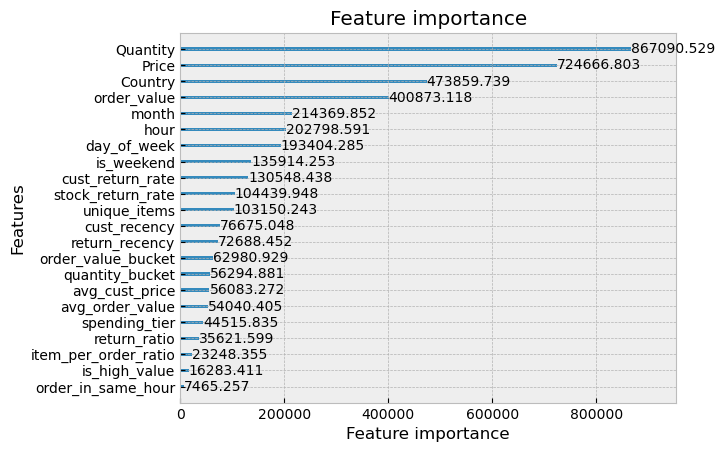

In [405]:
# Plot with the names
ax = lgb.plot_importance(final_model, importance_type='gain')
ax.set_yticklabels(features[::-1]) # Reverse names to match the plot order
plt.show()


In [162]:
X_validation = test_df.drop(columns=['is_return'])
X_validation['Country'] = encoder.transform(X_validation['Country'])
X_validation_scaled = scaler.transform(X_validation)

In [163]:
y_pred = (final_model.predict_proba(X_validation_scaled)[:,1]>0.72).astype(int)

In [168]:
print(classification_report(y_val,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.74      0.84    134749
           1       0.04      0.55      0.07      2633

    accuracy                           0.73    137382
   macro avg       0.51      0.64      0.46    137382
weighted avg       0.97      0.73      0.83    137382



In [167]:
y_pred = final_model.predict(X_validation_scaled)

### Logistic Regression

In [157]:
from sklearn.linear_model import LogisticRegression

In [158]:
lr_model = LogisticRegression(C=0.01,max_iter=200,random_state=42,n_jobs=-1)

In [160]:
lr_model.fit(X_train_resampled,y_train_resampled)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [207]:
lr_y_pred = (lr_model.predict_proba(X_val)[:,1] > 0.7).astype(int)

In [208]:
confusion_matrix(y_val,lr_y_pred)

array([[134746,      3],
       [  2632,      1]], dtype=int64)

In [209]:
print(classification_report(y_val,lr_y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    134749
           1       0.25      0.00      0.00      2633

    accuracy                           0.98    137382
   macro avg       0.62      0.50      0.50    137382
weighted avg       0.97      0.98      0.97    137382



### Random Forest

In [167]:
from sklearn.ensemble import RandomForestClassifier

In [168]:
rf_model = RandomForestClassifier(
    n_estimators=400,bootstrap=True,
    criterion='entropy',max_depth=12,
    n_jobs=-1,random_state=42,
    min_samples_split=3,
)

In [169]:
rf_model.fit(X_tr_res,y_tr_res)

,n_estimators,400
,criterion,'entropy'
,max_depth,12
,min_samples_split,3
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [170]:
rf_y_pred = (rf_model.predict_proba(X_val)[:,1] > 0.7).astype(int)

In [171]:
confusion_matrix(y_val,rf_y_pred)

array([[105525,   1859],
       [  1291,   1230]])

In [172]:
print(classification_report(y_val,rf_y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99    107384
           1       0.40      0.49      0.44      2521

    accuracy                           0.97    109905
   macro avg       0.69      0.74      0.71    109905
weighted avg       0.97      0.97      0.97    109905



In [125]:
rf_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': 12,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 3,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 400,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

### XGBoost

In [195]:
from xgboost import XGBClassifier

In [196]:
xgb_model = XGBClassifier(
    n_estimators= 608, max_depth= 8, 
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    learning_rate= 0.14587621364277914, subsample=0.8162266852324389, 
    colsample_bytree= 0.7057247836490844, gamma= 0.07625629222608954, 
    min_child_weight= 2, reg_alpha= 1.8058595411551832,
    reg_lambda= 9.22761628921285, scale_pos_weight= 5.469033195550583
)

In [197]:
xgb_model.fit(X_train_resampled,y_train_resampled)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7057247836490844
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [198]:
y_pred = (xgb_model.predict_proba(X_test_scaled)[:,1] > 0.7).astype(int)

In [199]:
print(confusion_matrix(y_val,y_pred))

[[86679 48070]
 [ 1056  1577]]


In [201]:
# report['1']

In [202]:
print(classification_report(y_val,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.64      0.78    134749
           1       0.03      0.60      0.06      2633

    accuracy                           0.64    137382
   macro avg       0.51      0.62      0.42    137382
weighted avg       0.97      0.64      0.77    137382



In [203]:
features = X_train.columns.to_list()

In [205]:
# 2. Map these names back to the XGBoost booster object
xgb_model.get_booster().feature_names = features

# 3. Plot the importance (using 'gain' is usually best for decision-making)
plt.figure(figsize=(10, 8))
plot_importance(xgb_model, importance_type='gain', title='Final Model Feature Importance (Gain)')
plt.show()

NameError: name 'plot_importance' is not defined

<Figure size 1000x800 with 0 Axes>

In [207]:
# ############ hyperparameter tuning
# import optuna
# from xgboost import XGBClassifier
# from sklearn.metrics import f1_score

# def objective(trial):
#     # 1. Hyperparameter Search Space
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
#         'max_depth': trial.suggest_int('max_depth', 3, 10),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        
#         # Balance weight: Higher value helps the '1' (Return) class
#         'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 50),
#         'tree_method': 'hist',  # Fast for large datasets
#         'random_state': 42,
#         'n_jobs': -1
#     }

#     # 2. Model Training
#     # Using your pre-split temporal training/validation sets
#     model = XGBClassifier(**params,verbosity=1)
#     model.fit(X_tr_res, y_tr_res)
    
#     # 3. Prediction & Evaluation
#     preds = model.predict(X_val)
    
#     # We maximize the F1-score for the minority class (1)
#     score = f1_score(y_val, preds)
    
#     return score

In [6]:
# # 4. Create and Run the Study
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)

# # 5. Output Results
# print(f"Best F1 Score: {study.best_value:.4f}")
# print("Best Parameters:", study.best_params)

In [210]:
# params = study.best_params

In [211]:
# final_model = XGBClassifier(**params)

In [212]:
# final_model.fit(X_tr_res,y_tr_res)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9218343641056514
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [213]:
# y_pred = (final_model.predict_proba(X_val)[:,1]>0.7).astype(int)

In [214]:
# confusion_matrix(y_val,y_pred)

array([[106808,    576],
       [  1512,   1009]])

In [215]:
# print(classification_report(y_val,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99    107384
           1       0.64      0.40      0.49      2521

    accuracy                           0.98    109905
   macro avg       0.81      0.70      0.74    109905
weighted avg       0.98      0.98      0.98    109905

